# Main Figure v2 — Standalone Panels for Illustrator Assembly

Each panel is saved as an **independent figure** (PDF + PNG) with an
accompanying **source-data TSV**. Assemble in Illustrator.

| Panel | File prefix | Content |
|-------|-------------|---------|
| A1 | `panel_A1_strip_box` | Gene agreement — strip + boxplot |
| A2 | `panel_A2_horiz_bar` | Gene agreement — horizontal bar + strip |
| A3 | `panel_A3_violin` | Gene agreement — violin |
| B1 | `panel_B1_intron_chain_8class` | Transcript concordance Ensembl→CAT (8-class) |
| B2 | `panel_B2_intron_chain_4group` | Transcript concordance Ensembl→CAT (4-group) |
| B1_cat | `panel_B1cat_intron_chain_8class` | Transcript concordance CAT→Ensembl (8-class) |
| B_compare | `panel_B_compare_directions` | Side-by-side Ens→CAT vs CAT→Ens (4-group) |
| B_ratio | `panel_B_ratio` | CAT/Ensembl transcript count ratio by biotype |
| B_supp | `panel_Bsupp_full_denom` | Full-denominator concordance (Ensembl→CAT) |
| C | `panel_C_jaccard_by_biotype` | Jaccard index distribution |
| D | `panel_D_cds_concordance` | CDS concordance (protein-coding) |
| E | `panel_E_divergence` | GRCh38 divergence categories |

Every `_data.tsv` contains exactly the numbers used to draw the plot.

In [126]:
import os, shutil
from pathlib import Path
import matplotlib as mpl
from matplotlib import font_manager as fm

# Use local scratch for Matplotlib cache to avoid stale NFS handles
try:
    MPLDIR = Path('/tmp') / f"{os.environ.get('USER','user')}-mplconfig"
    MPLDIR.mkdir(parents=True, exist_ok=True)
    os.environ['MPLCONFIGDIR'] = str(MPLDIR)
    import matplotlib
    ttf_src = Path(matplotlib.get_data_path())/'fonts'/'ttf'
    ttf_dst = MPLDIR/'ttf'
    shutil.copytree(ttf_src, ttf_dst, dirs_exist_ok=True)
    for f in ttf_dst.glob('*.ttf'):
        fm.fontManager.addfont(str(f))
    fm._load_fontmanager(try_read_cache=False)
    mpl.rcParams.update({'svg.fonttype':'none', 'pdf.fonttype':42, 'ps.fonttype':42,
                         'font.family':'DejaVu Sans'})
except Exception as e:
    print('Font init warning:', e)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
import gc

warnings.filterwarnings('ignore')

# Publication-quality defaults
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 8,
    'axes.labelsize': 9,
    'axes.titlesize': 10,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 7,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

print(f'pandas {pd.__version__}, numpy {np.__version__}')

pandas 3.0.1, numpy 2.4.2


In [127]:
# ── Paths ──────────────────────────────────────────────────────────────────
OUTPUT_DIR  = Path('/hps/nobackup/flicek/ensembl/genebuild/jackt/hprc/hprc-qc/results')

QC_DIR         = OUTPUT_DIR / 'qc_metrics'
RESULTS_DIR    = OUTPUT_DIR / 'results'
SUMMARY_DIR    = OUTPUT_DIR / 'summary_stats'
FIGURE_DIR     = OUTPUT_DIR / 'figures'
INTRON_DIR     = OUTPUT_DIR / 'intermediate_spreadsheets' / 'intron_chain'
CDS_DIR        = OUTPUT_DIR / 'intermediate_spreadsheets' / 'coding_integrity'
DIV_DIR        = OUTPUT_DIR / 'intermediate_spreadsheets' / 'divergence'
FIGURE_DIR.mkdir(exist_ok=True, parents=True)

def save_panel(fig, prefix):
    """Save a standalone panel as PDF + PNG."""
    fig.savefig(FIGURE_DIR / f'{prefix}.pdf', bbox_inches='tight')
    fig.savefig(FIGURE_DIR / f'{prefix}.png', dpi=300, bbox_inches='tight')
    print(f'  Saved {prefix}.{{pdf,png}}')

def save_data(df, prefix):
    """Save source data TSV alongside a panel."""
    path = FIGURE_DIR / f'{prefix}_data.tsv'
    df.to_csv(path, sep='\t', index=False)
    print(f'  Saved {prefix}_data.tsv  ({len(df)} rows)')

print(f'Output:  {OUTPUT_DIR}')
print(f'Figures: {FIGURE_DIR}')

Output:  /hps/nobackup/flicek/ensembl/genebuild/jackt/hprc/hprc-qc/results
Figures: /hps/nobackup/flicek/ensembl/genebuild/jackt/hprc/hprc-qc/results/figures


In [128]:
# ── Colour palette ────────────────────────────────────────────────────────

# 8-class intron chain colours (visually grouped)
CLASS_COLORS = {
    'Exact_Match':    '#2a9d8f',
    'Intron_Match':   '#264653',
    'Intron_Subset':  '#457b9d',
    'Intron_Superset':'#74a9cf',
    'Partial_5':      '#e9c46a',
    'Partial_3':      '#f4a261',
    'Other_Partial':  '#e76f51',
    'No_Match':       '#c1121f',
}
CLASS_LABELS = {
    'Exact_Match':     'Exact match',
    'Intron_Match':    'Intron chain match',
    'Intron_Subset':   'Intron subset',
    'Intron_Superset': 'Intron superset',
    'Partial_5':       "Partial (5')",
    'Partial_3':       "Partial (3')",
    'Other_Partial':   'Other partial',
    'No_Match':        'No match',
}
CLASSIFICATION_ORDER = [
    'Exact_Match', 'Intron_Match', 'Intron_Subset', 'Intron_Superset',
    'Partial_5', 'Partial_3', 'Other_Partial', 'No_Match',
]

# 4-group collapsed
GROUP_4_MAP = {
    'Exact_Match':    'Exact match',
    'Intron_Match':   'Same intron chain',
    'Intron_Subset':  'Same intron chain',
    'Intron_Superset':'Same intron chain',
    'Partial_5':      'Partial overlap',
    'Partial_3':      'Partial overlap',
    'Other_Partial':  'Partial overlap',
    'No_Match':       'No match',
}
GROUP_4_COLORS = {
    'Exact match':       '#2a9d8f',
    'Same intron chain': '#457b9d',
    'Partial overlap':   '#f4a261',
    'No match':          '#c1121f',
}
GROUP_4_ORDER = ['Exact match', 'Same intron chain', 'Partial overlap', 'No match']

BIOTYPE_ORDER  = ['protein_coding', 'lncRNA', 'pseudogene', 'other_ncRNA', 'other']
BIOTYPE_LABELS = {
    'protein_coding': 'Protein-coding',
    'lncRNA':         'lncRNA',
    'pseudogene':     'Pseudogene',
    'other_ncRNA':    'Other ncRNA',
    'other':          'Other',
}

---
## Load all data

In [129]:
# ── Gene presence per assembly ────────────────────────────────────────────
funnel_file = SUMMARY_DIR / 'funnel_rung1_gene_presence_per_asm.tsv'
if funnel_file.exists():
    gene_pres = pd.read_csv(funnel_file, sep='\t')
    print(f'Loaded gene presence: {len(gene_pres)} assemblies')
else:
    import re
    ACC_RE = re.compile(r'(GC[AF]_\d+\.\d+)')
    files = sorted(QC_DIR.rglob('*_gene_presence.tsv'))
    print(f'Computing gene presence from {len(files)} files...')
    rows = []
    for f in files:
        m = ACC_RE.search(f.name)
        acc = m.group(1) if m else f.stem
        df = pd.read_csv(f, sep='\t')
        for col in ['present_in_ensembl', 'present_in_cat']:
            df[col] = df[col].map({'True': True, 'False': False, True: True, False: False})
        df = df[~df['gene_name'].str.match(r'^ENSG', na=False)]
        n_union = len(df)
        n_both = ((df['present_in_ensembl']) & (df['present_in_cat'])).sum()
        rows.append({'assembly_accession': acc,
                     'n_union_loci': n_union, 'n_both_loci': int(n_both),
                     'pct_gene_presence': n_both / n_union if n_union > 0 else np.nan})
    gene_pres = pd.DataFrame(rows)
    print(f'Computed gene presence: {len(gene_pres)} assemblies')

gene_pres['pct'] = gene_pres['pct_gene_presence'] * 100

# ── Intron chain classification ───────────────────────────────────────────
ic_file = INTRON_DIR / 'intron_chain_by_biotype_per_assembly.tsv'
if ic_file.exists():
    ic_data = pd.read_csv(ic_file, sep='\t')
    print(f'Loaded intron chain: {len(ic_data):,} rows, '
          f'{ic_data["assembly_accession"].nunique()} assemblies')
    if 'direction' in ic_data.columns:
        for d in ic_data['direction'].unique():
            n = len(ic_data[ic_data['direction'] == d])
            print(f'  {d}: {n:,} rows')
    else:
        # Legacy format: no direction column → assume Ensembl_to_CAT
        ic_data['direction'] = 'Ensembl_to_CAT'
        print('  (legacy format — added direction=Ensembl_to_CAT)')
else:
    print(f'WARNING: {ic_file} not found — run aggregate_intron_chain_by_biotype.py first')
    ic_data = pd.DataFrame()

# ── Transcript count ratios ───────────────────────────────────────────────
ratio_file = INTRON_DIR / 'transcript_count_ratio_per_assembly.tsv'
if ratio_file.exists():
    ratio_data = pd.read_csv(ratio_file, sep='\t')
    print(f'Loaded transcript count ratios: {len(ratio_data):,} rows')
else:
    ratio_data = pd.DataFrame()
    print(f'No transcript count ratio file found.')

# ── Jaccard by biotype ────────────────────────────────────────────────────
jac_file = INTRON_DIR / 'jaccard_by_biotype_per_assembly.tsv'
jac_data = pd.read_csv(jac_file, sep='\t') if jac_file.exists() else pd.DataFrame()
if not jac_data.empty:
    print(f'Loaded Jaccard: {len(jac_data):,} rows')

# ── CDS concordance ──────────────────────────────────────────────────────
cds_asm_file = CDS_DIR / 'coding_integrity_per_assembly.tsv'
cds_asm = pd.read_csv(cds_asm_file, sep='\t') if cds_asm_file.exists() else pd.DataFrame()
if not cds_asm.empty:
    print(f'Loaded CDS: {len(cds_asm)} assemblies')

# ── GRCh38 divergence ─────────────────────────────────────────────────────
div_asm_file = DIV_DIR / 'grch38_divergence_per_assembly.tsv'
div_asm = pd.read_csv(div_asm_file, sep='\t') if div_asm_file.exists() else pd.DataFrame()
if not div_asm.empty:
    print(f'Loaded divergence: {div_asm["assembly_accession"].nunique()} assemblies')

Loaded gene presence: 462 assemblies
Loaded intron chain: 36,960 rows, 462 assemblies
  Ensembl_to_CAT: 18,480 rows
  CAT_to_Ensembl: 18,480 rows
Loaded transcript count ratios: 2,310 rows
Loaded Jaccard: 2,310 rows
Loaded CDS: 462 assemblies
Loaded divergence: 458 assemblies


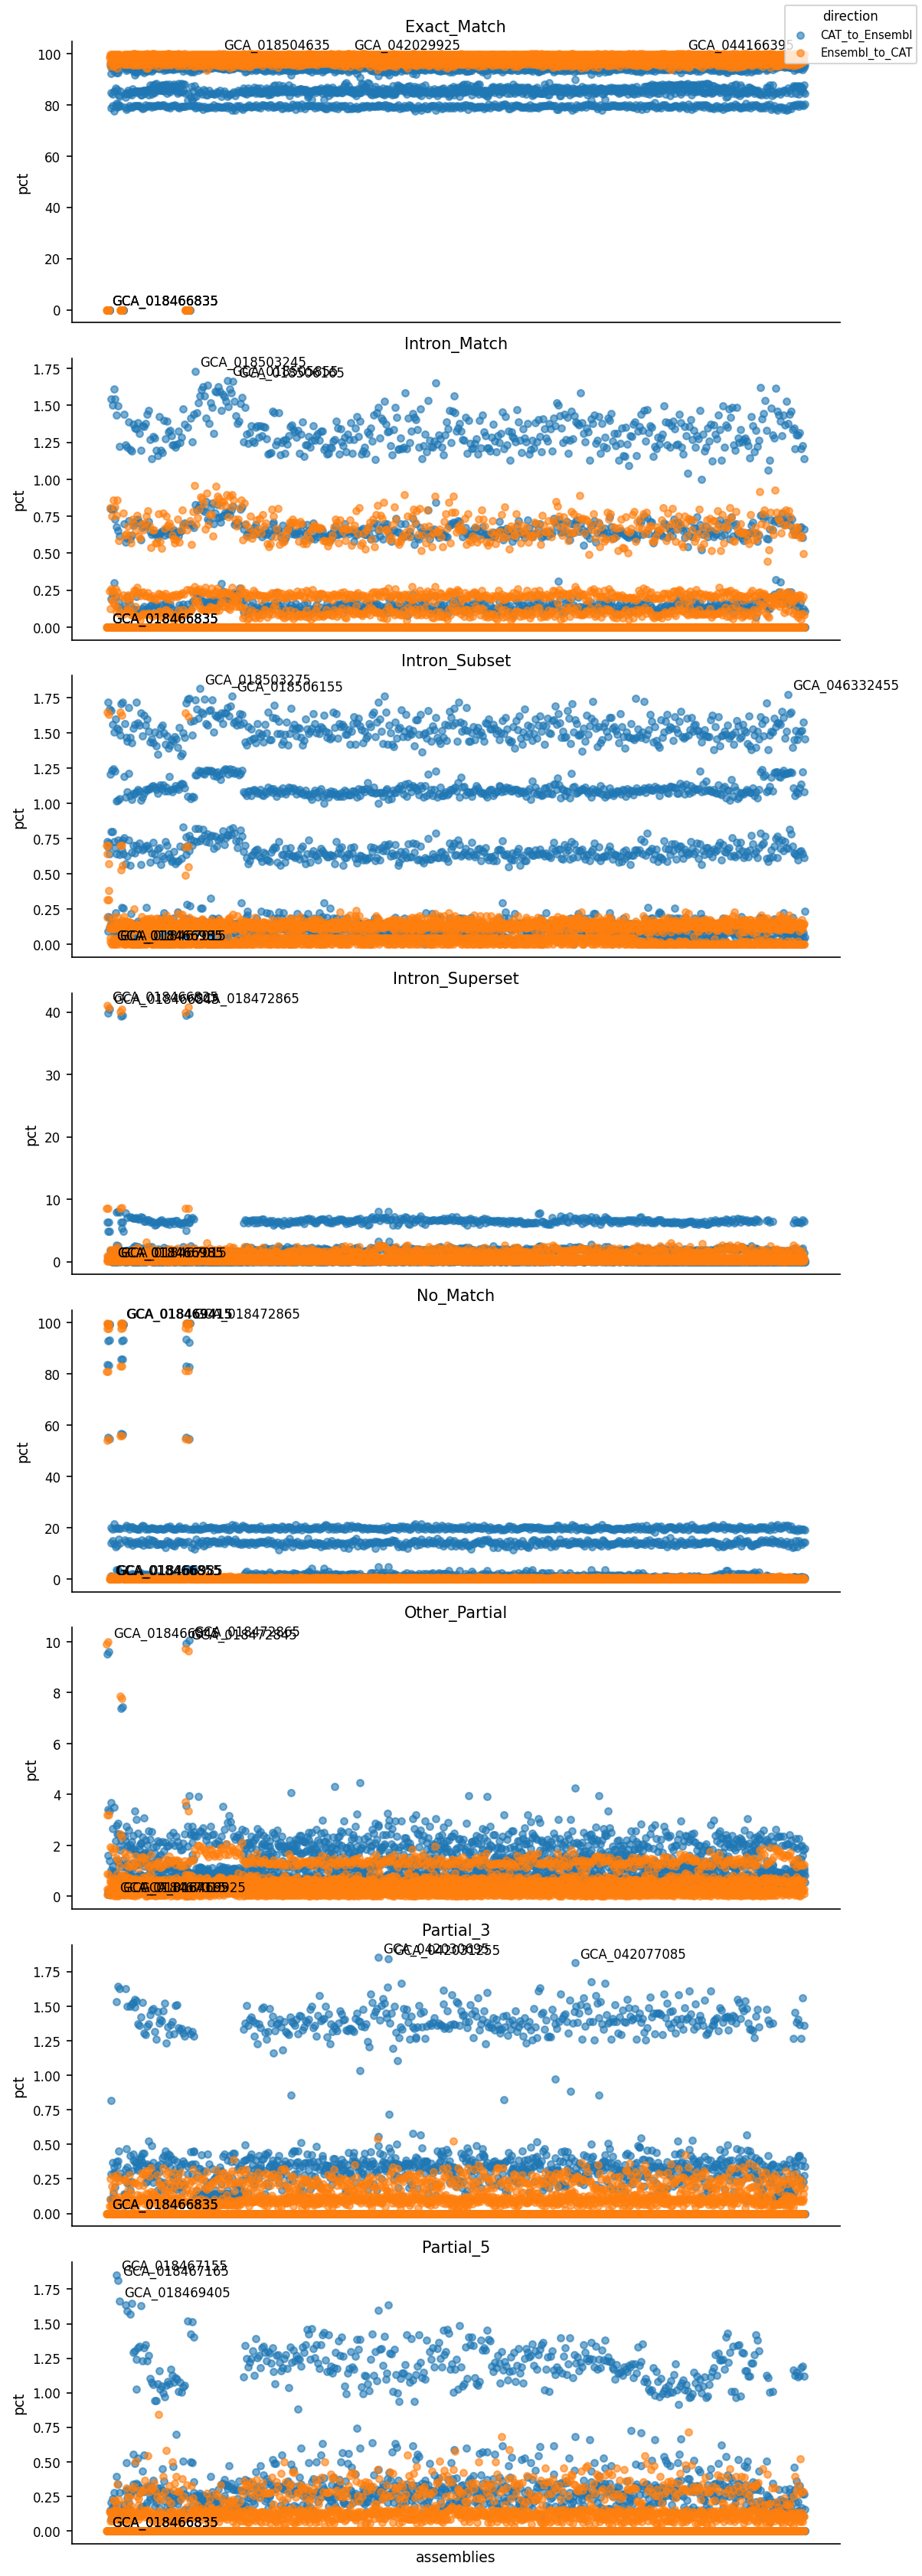

In [168]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = ic_data.copy()

classifications = sorted(df["classification"].unique())
directions = sorted(df["direction"].unique())

direction_colors = {
    directions[0]: "tab:blue",
    directions[1]: "tab:orange" if len(directions) > 1 else "tab:blue"
}

direction_offset = {
    directions[0]: -0.12,
    directions[1]:  0.12 if len(directions) > 1 else 0
}

fig, axes = plt.subplots(
    len(classifications), 1,
    figsize=(8, 2.8 * len(classifications))
)

if len(classifications) == 1:
    axes = [axes]

for ax, cls in zip(axes, classifications):

    sub = df[df["classification"] == cls].copy().reset_index(drop=True)
    sub["x"] = np.arange(len(sub))

    for direction, g in sub.groupby("direction"):

        x = g["x"] + direction_offset[direction]

        ax.scatter(
            x,
            g["pct"],
            color=direction_colors[direction],
            alpha=0.6,
            s=18,
            label=direction
        )

    # ---- label only extreme points ----
    top = sub.nlargest(3, "pct")
    bottom = sub.nsmallest(3, "pct")
    label_points = pd.concat([top, bottom])

    for _, row in label_points.iterrows():
        ax.annotate(
            row["assembly_accession"].split(".")[0],
            (row["x"], row["pct"]),
            xytext=(3,3),
            textcoords="offset points",
            fontsize=8
        )

    ax.set_title(cls)
    ax.set_ylabel("pct")
    ax.set_xticks([])

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="direction", loc="upper right")

axes[-1].set_xlabel("assemblies")

plt.tight_layout()
plt.show()

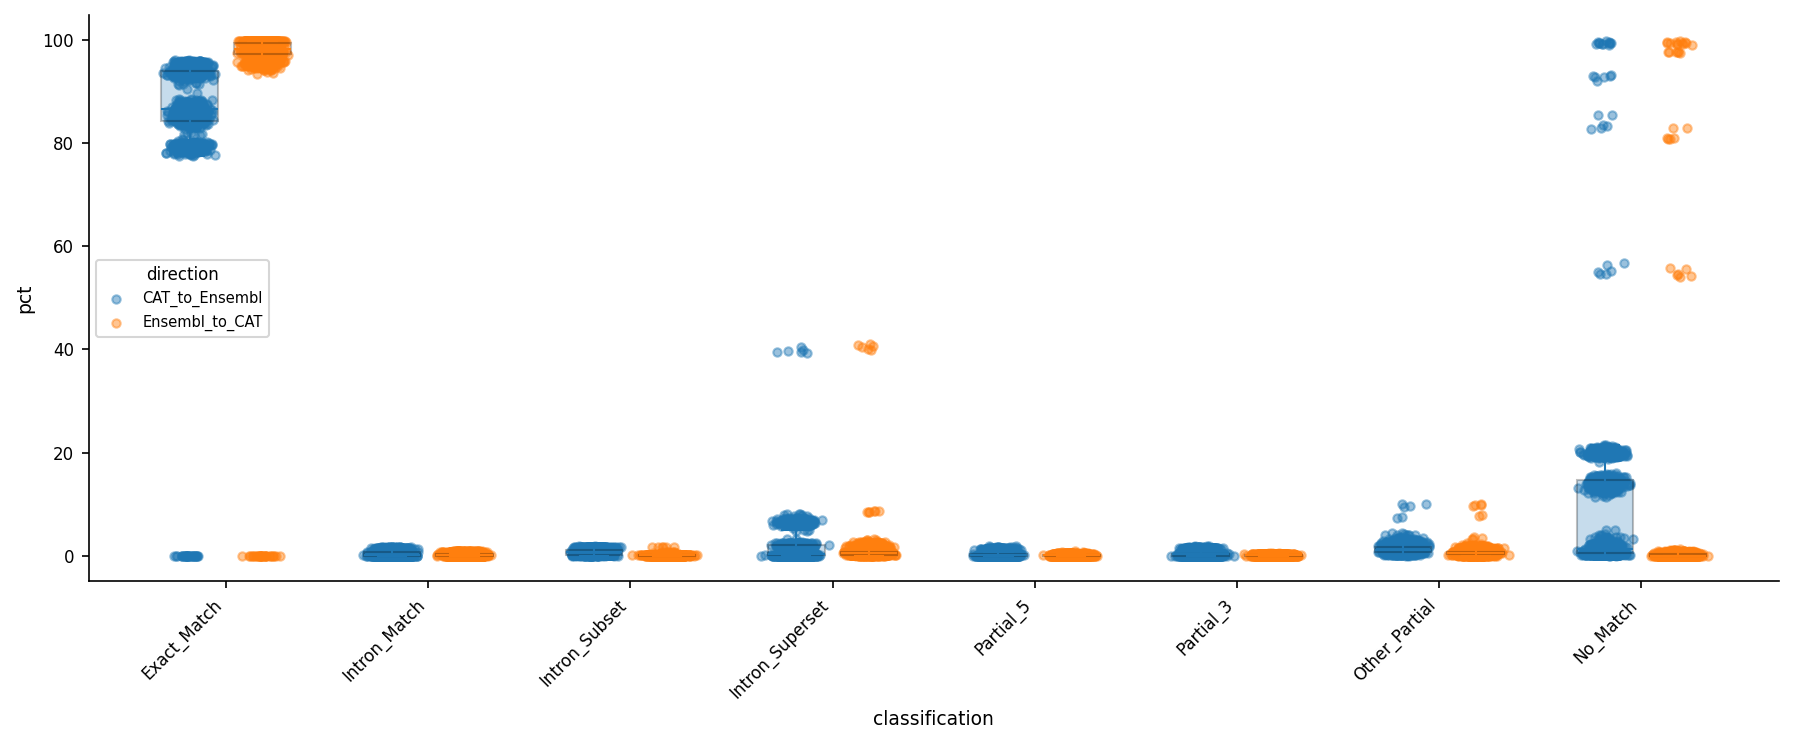

In [169]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = ic_data.copy()

# Order classifications in a sensible way
class_order = [
    "Exact_Match",
    "Intron_Match",
    "Intron_Subset",
    "Intron_Superset",
    "Partial_5",
    "Partial_3",
    "Other_Partial",
    "No_Match",
]
class_order = [c for c in class_order if c in df["classification"].unique()]

dir_order = sorted(df["direction"].unique())
colors = {
    dir_order[0]: "tab:blue",
    dir_order[1]: "tab:orange" if len(dir_order) > 1 else "tab:blue",
}
offsets = {
    dir_order[0]: -0.18,
    dir_order[1]:  0.18 if len(dir_order) > 1 else 0.0,
}

xpos = {c: i for i, c in enumerate(class_order)}

fig, ax = plt.subplots(figsize=(12, 5))

# light boxplots per direction
for direction in dir_order:
    data = []
    positions = []
    for cls in class_order:
        vals = df.loc[
            (df["classification"] == cls) & (df["direction"] == direction),
            "pct"
        ].values
        data.append(vals)
        positions.append(xpos[cls] + offsets[direction])

    bp = ax.boxplot(
        data,
        positions=positions,
        widths=0.28,
        patch_artist=True,
        showfliers=False
    )
    for patch in bp["boxes"]:
        patch.set_alpha(0.25)
        patch.set_facecolor(colors[direction])
    for key in ["whiskers", "caps", "medians"]:
        for item in bp[key]:
            item.set_color(colors[direction])

# jittered points
rng = np.random.default_rng(42)
for direction in dir_order:
    sub = df[df["direction"] == direction].copy()
    x = sub["classification"].map(xpos).astype(float).to_numpy()
    x = x + offsets[direction] + rng.normal(0, 0.04, size=len(sub))

    ax.scatter(
        x,
        sub["pct"],
        s=16,
        alpha=0.45,
        color=colors[direction],
        label=direction
    )

ax.set_xticks(range(len(class_order)))
ax.set_xticklabels(class_order, rotation=45, ha="right")
ax.set_ylabel("pct")
ax.set_xlabel("classification")
ax.legend(title="direction")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

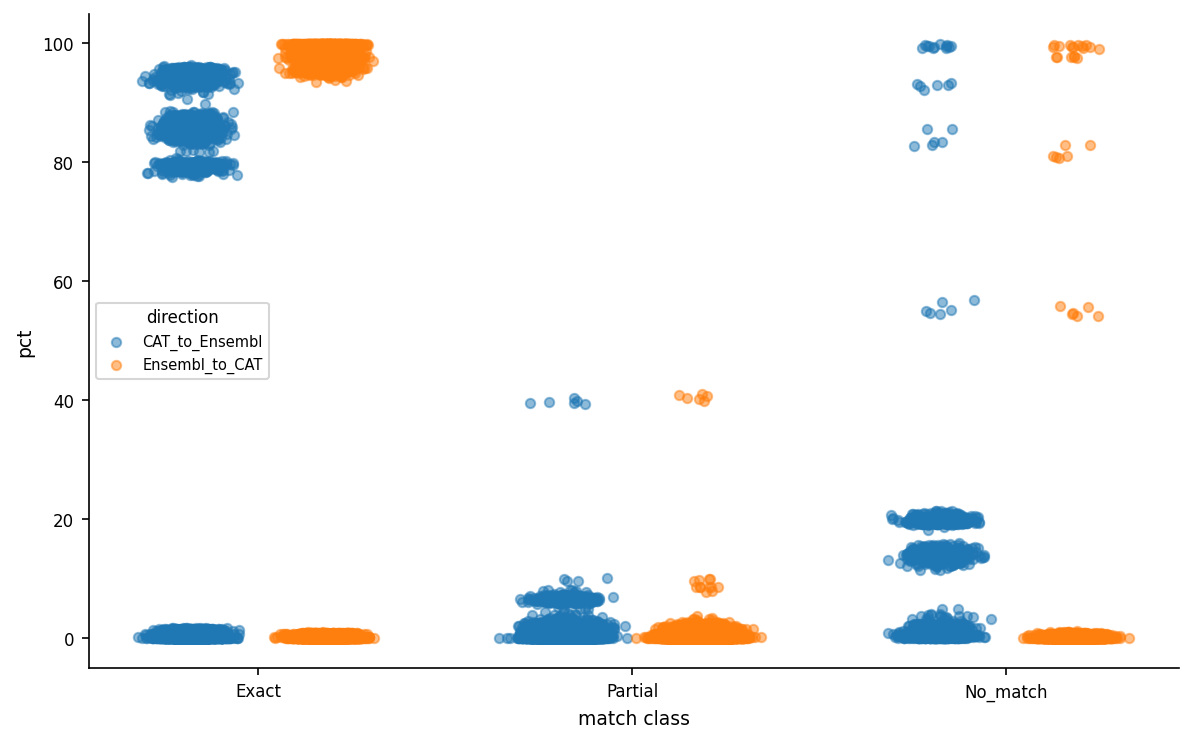

In [170]:
# Collapse classifications
collapse_map = {
    "Exact_Match": "Exact",
    "Intron_Match": "Exact",
    "No_Match": "No_match"
}

df["match_class"] = df["classification"].map(collapse_map).fillna("Partial")

order = ["Exact", "Partial", "No_match"]
dir_order = sorted(df["direction"].unique())

colors = {
    dir_order[0]: "tab:blue",
    dir_order[1]: "tab:orange" if len(dir_order) > 1 else "tab:blue"
}

offsets = {
    dir_order[0]: -0.18,
    dir_order[1]: 0.18 if len(dir_order) > 1 else 0
}

xpos = {c: i for i, c in enumerate(order)}

fig, ax = plt.subplots(figsize=(8,5))

rng = np.random.default_rng(42)

for direction in dir_order:
    sub = df[df["direction"] == direction]

    x = sub["match_class"].map(xpos).astype(float)
    x = x + offsets[direction] + rng.normal(0, 0.04, size=len(sub))

    ax.scatter(
        x,
        sub["pct"],
        s=20,
        alpha=0.5,
        color=colors[direction],
        label=direction
    )

ax.set_xticks(range(len(order)))
ax.set_xticklabels(order)
ax.set_ylabel("pct")
ax.set_xlabel("match class")

ax.legend(title="direction")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

---
## Panel A — Gene-level agreement

Three standalone prototypes. All share the same source data TSV.

In [173]:
# ── Source data ───────────────────────────────────────────────────────────
panel_A_data = gene_pres[['assembly_accession', 'n_union_loci', 'n_both_loci',
                           'pct_gene_presence', 'pct']].copy()
panel_A_data = panel_A_data.rename(columns={'pct': 'pct_gene_presence_x100'})
save_data(panel_A_data, 'panel_A_gene_agreement')

vals = gene_pres['pct'].dropna()
med = vals.median()
print(f'  Median: {med:.1f}%  '
      f'IQR: {vals.quantile(0.25):.1f}\u2013{vals.quantile(0.75):.1f}%  '
      f'n={len(vals)}')

  Saved panel_A_gene_agreement_data.tsv  (462 rows)
  Median: 97.5%  IQR: 97.1–97.8%  n=462


  Saved panel_A1_strip_box.{pdf,png}


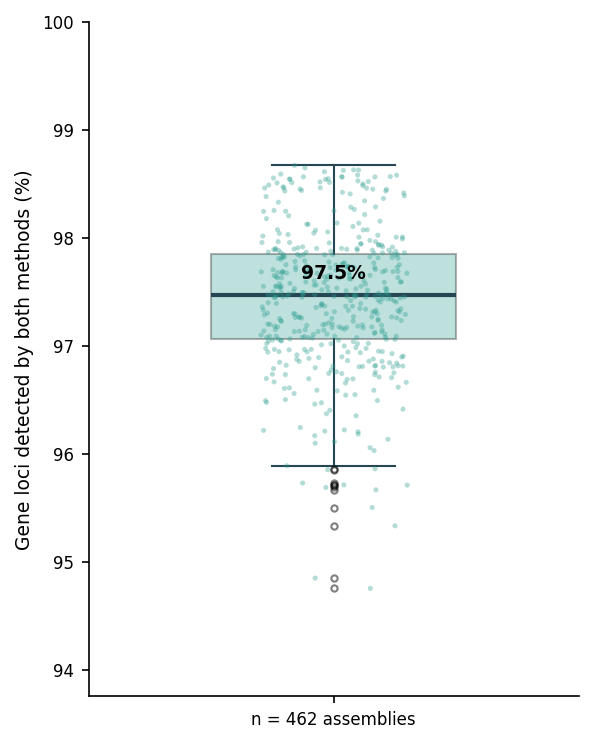

In [174]:
# ── A1: Strip + Boxplot ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(4, 5))
ax.boxplot(vals, vert=True, widths=0.5, patch_artist=True,
           boxprops=dict(facecolor='#2a9d8f', alpha=0.3),
           medianprops=dict(color='#264653', linewidth=2),
           whiskerprops=dict(color='#264653'),
           capprops=dict(color='#264653'),
           flierprops=dict(marker='o', markersize=3, alpha=0.5))
jitter = np.random.default_rng(42).uniform(-0.15, 0.15, len(vals))
ax.scatter(np.ones(len(vals)) + jitter, vals, s=6, alpha=0.35,
           color='#2a9d8f', edgecolors='none', zorder=3)
ax.set_ylabel('Gene loci detected by both methods (%)')
ax.set_xticks([1]); ax.set_xticklabels([f'n = {len(vals)} assemblies'])
ax.set_ylim(max(vals.min() - 1, 90), 100)
ax.text(1, med + 0.15, f'{med:.1f}%', ha='center', fontsize=9, fontweight='bold')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
save_panel(fig, 'panel_A1_strip_box')
plt.show()

  Saved panel_A2_horiz_bar.{pdf,png}


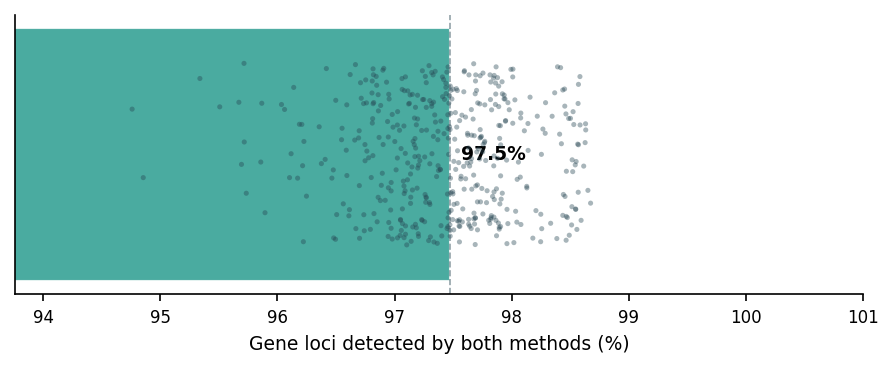

In [175]:
# ── A2: Horizontal bar + dot strip ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 2.5))
ax.barh(0, med, height=0.5, color='#2a9d8f', alpha=0.85, edgecolor='white')
ax.text(med + 0.1, 0, f'{med:.1f}%', va='center', fontsize=9, fontweight='bold')
jitter_y = np.random.default_rng(42).uniform(-0.18, 0.18, len(vals))
ax.scatter(vals, jitter_y, s=6, alpha=0.4, color='#264653', edgecolors='none', zorder=3)
ax.set_xlabel('Gene loci detected by both methods (%)')
ax.set_yticks([])
ax.set_xlim(max(vals.min() - 1, 90), 101)
ax.axvline(med, color='#264653', linewidth=0.8, linestyle='--', alpha=0.5)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
save_panel(fig, 'panel_A2_horiz_bar')
plt.show()

  Saved panel_A3_violin.{pdf,png}


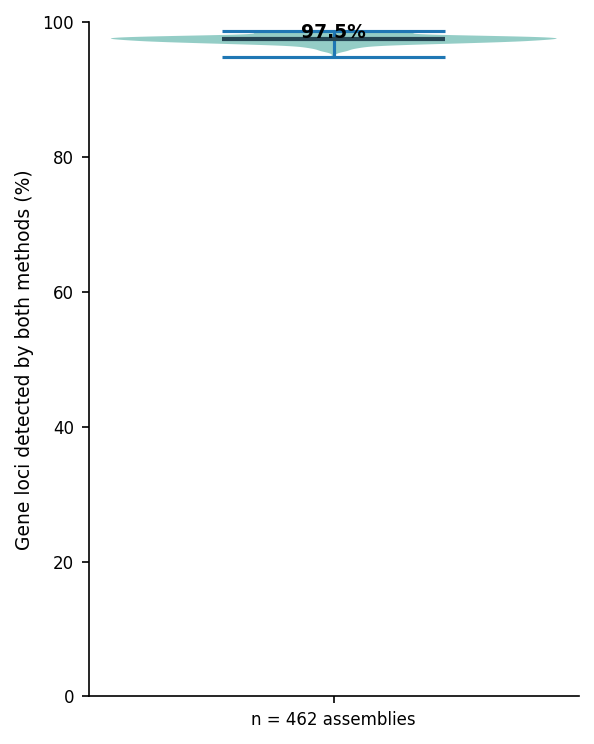

In [176]:
# ── A3: Violin ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(4, 5))
parts = ax.violinplot(vals, vert=True, showmedians=True, showextrema=True)
for pc in parts['bodies']:
    pc.set_facecolor('#2a9d8f'); pc.set_alpha(0.5)
parts['cmedians'].set_color('#264653'); parts['cmedians'].set_linewidth(2)
ax.set_ylabel('Gene loci detected by both methods (%)')
ax.set_xticks([1]); ax.set_xticklabels([f'n = {len(vals)} assemblies'])
# ax.set_ylim(max(vals.min() - 1, 90), 100)
ax.set_ylim(0, 100)

ax.text(1, med + 0.15, f'{med:.1f}%', ha='center', fontsize=9, fontweight='bold')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
save_panel(fig, 'panel_A3_violin')
plt.show()

---
## Panel B — Transcript concordance by biotype

Two standalone figures: B1 (8-class detail) and B2 (4-group collapsed).

**Key design choice:** These panels operate at the **transcript level**, not the
gene level. Each Ensembl transcript is classified by its best CAT match, then
we count transcripts per classification. This avoids the optimistic bias of
"best-per-gene" aggregation, where a gene with 1/10 exact-matching transcripts
would look the same as a gene with 10/10.

In [177]:
if ic_data.empty:
    print('Skipping Panel B — no intron chain data.')
else:
    # The intron chain data now has a `direction` column with two values:
    #   Ensembl_to_CAT: "can each Ensembl transcript find a CAT match?"
    #   CAT_to_Ensembl: "can each CAT transcript find an Ensembl match?"
    #
    # The Ensembl→CAT direction is typically more favorable because CAT
    # annotates more transcripts per gene, so most Ensembl transcripts
    # can find a match in the larger set. The CAT→Ensembl direction
    # reveals extra CAT transcripts that have no Ensembl counterpart.

    # Compute median + IQR per direction × biotype × classification
    medians_by_dir = {}
    stats_by_dir = {}

    for direction in ['Ensembl_to_CAT', 'CAT_to_Ensembl']:
        dir_data = ic_data[ic_data['direction'] == direction].copy()
        if dir_data.empty:
            print(f'  No data for direction: {direction}')
            continue

        stats = (
            dir_data.groupby(['biotype', 'classification'])['pct']
            .agg(
                median_pct='median',
                q25_pct=lambda x: x.quantile(0.25),
                q75_pct=lambda x: x.quantile(0.75),
                n_assemblies='count'
            )
            .reset_index()
        )
        stats_by_dir[direction] = stats

        medians = (
            stats.pivot(index='biotype', columns='classification', values='median_pct')
            .reindex(index=BIOTYPE_ORDER, columns=CLASSIFICATION_ORDER, fill_value=0)
        )
        medians_by_dir[direction] = medians

    # Backward-compat variables for existing Panel B cells
    stats_8 = stats_by_dir.get('Ensembl_to_CAT', pd.DataFrame())
    medians_8 = medians_by_dir.get('Ensembl_to_CAT', pd.DataFrame())

    # Compute collapsed 4-group summaries CORRECTLY:
    # collapse first at the per-assembly level, then compute median/IQR
    medians_4_by_dir = {}
    stats_4_by_dir = {}

    for direction in ['Ensembl_to_CAT', 'CAT_to_Ensembl']:
        dir_data = ic_data[ic_data['direction'] == direction].copy()
        if dir_data.empty:
            continue

        dir_data['group'] = dir_data['classification'].map(GROUP_4_MAP)

        # Sum pct within each assembly × biotype × collapsed group
        collapsed = (
            dir_data.groupby(['assembly_accession', 'biotype', 'group'], as_index=False)['pct']
            .sum()
        )

        # Now compute summary stats across assemblies
        stats_4 = (
            collapsed.groupby(['biotype', 'group'])['pct']
            .agg(
                median_pct='median',
                q25_pct=lambda x: x.quantile(0.25),
                q75_pct=lambda x: x.quantile(0.75),
                n_assemblies='count'
            )
            .reset_index()
        )
        stats_4_by_dir[direction] = stats_4

        medians_4 = (
            stats_4.pivot(index='biotype', columns='group', values='median_pct')
            .reindex(index=BIOTYPE_ORDER, columns=GROUP_4_ORDER, fill_value=0)
        )
        medians_4_by_dir[direction] = medians_4

    # Backward-compat
    stats_4 = stats_4_by_dir.get('Ensembl_to_CAT', pd.DataFrame())
    medians_4 = medians_4_by_dir.get('Ensembl_to_CAT', pd.DataFrame())

    # Save source data
    save_data(
        stats_by_dir.get('Ensembl_to_CAT', pd.DataFrame()),
        'panel_B1_intron_chain_8class'
    )
    save_data(
        stats_by_dir.get('CAT_to_Ensembl', pd.DataFrame()),
        'panel_B1cat_intron_chain_8class'
    )
    save_data(
        stats_4_by_dir.get('Ensembl_to_CAT', pd.DataFrame()),
        'panel_B2_intron_chain_4group'
    )
    save_data(
        stats_4_by_dir.get('CAT_to_Ensembl', pd.DataFrame()),
        'panel_B2cat_intron_chain_4group'
    )

    for direction, label in [
        ('Ensembl_to_CAT', 'Ensembl → CAT'),
        ('CAT_to_Ensembl', 'CAT → Ensembl')
    ]:
        if direction in medians_by_dir:
            print(f'\n8-class medians — {label} (% of transcripts):')
            display(medians_by_dir[direction].round(1))

        if direction in medians_4_by_dir:
            print(f'\n4-group medians — {label} (% of transcripts):')
            display(medians_4_by_dir[direction].round(1))

    if not ratio_data.empty:
        ratio_med = (
            ratio_data.groupby('biotype')['ratio_cat_to_ens']
            .median()
            .reindex(BIOTYPE_ORDER)
        )
        print('\nMedian CAT/Ensembl transcript count ratio per biotype:')
        display(ratio_med.round(2))

  Saved panel_B1_intron_chain_8class_data.tsv  (40 rows)
  Saved panel_B1cat_intron_chain_8class_data.tsv  (40 rows)
  Saved panel_B2_intron_chain_4group_data.tsv  (20 rows)
  Saved panel_B2cat_intron_chain_4group_data.tsv  (20 rows)

8-class medians — Ensembl → CAT (% of transcripts):


classification,Exact_Match,Intron_Match,Intron_Subset,Intron_Superset,Partial_5,Partial_3,Other_Partial,No_Match
biotype,,,,,,,,
protein_coding,98.3,0.2,0.1,0.5,0.1,0.1,0.3,0.3
lncRNA,95.8,0.7,0.1,1.7,0.3,0.2,0.6,0.5
pseudogene,97.6,0.1,0.1,0.6,0.1,0.1,1.4,0.0
other_ncRNA,99.4,0.0,0.0,0.1,0.0,0.0,0.5,0.0
other,99.8,0.0,0.0,0.1,0.0,0.0,0.0,0.0



4-group medians — Ensembl → CAT (% of transcripts):


group,Exact match,Same intron chain,Partial overlap,No match
biotype,,,,
protein_coding,98.3,0.9,0.5,0.3
lncRNA,95.8,2.5,1.2,0.5
pseudogene,97.6,0.8,1.5,0.0
other_ncRNA,99.4,0.1,0.5,0.0
other,99.8,0.2,0.0,0.0



8-class medians — CAT → Ensembl (% of transcripts):


classification,Exact_Match,Intron_Match,Intron_Subset,Intron_Superset,Partial_5,Partial_3,Other_Partial,No_Match
biotype,,,,,,,,
protein_coding,86.4,0.6,1.1,6.4,1.2,1.4,1.5,1.2
lncRNA,93.9,1.3,0.7,1.9,0.3,0.4,1.2,0.5
pseudogene,95.0,0.1,1.5,0.3,0.2,0.3,2.2,0.3
other_ncRNA,79.3,0.0,0.1,0.0,0.0,0.0,0.7,19.8
other,85.2,0.0,0.1,0.1,0.0,0.0,0.6,14.0



4-group medians — CAT → Ensembl (% of transcripts):


group,Exact match,Same intron chain,Partial overlap,No match
biotype,,,,
protein_coding,86.4,8.2,4.1,1.2
lncRNA,93.9,3.8,1.8,0.5
pseudogene,95.0,1.9,2.7,0.3
other_ncRNA,79.3,0.1,0.7,19.8
other,85.2,0.2,0.6,14.0



Median CAT/Ensembl transcript count ratio per biotype:


biotype
protein_coding    1.14
lncRNA            1.02
pseudogene        1.03
other_ncRNA       1.25
other             1.17
Name: ratio_cat_to_ens, dtype: float64

  Saved panel_B1_intron_chain_8class.{pdf,png}


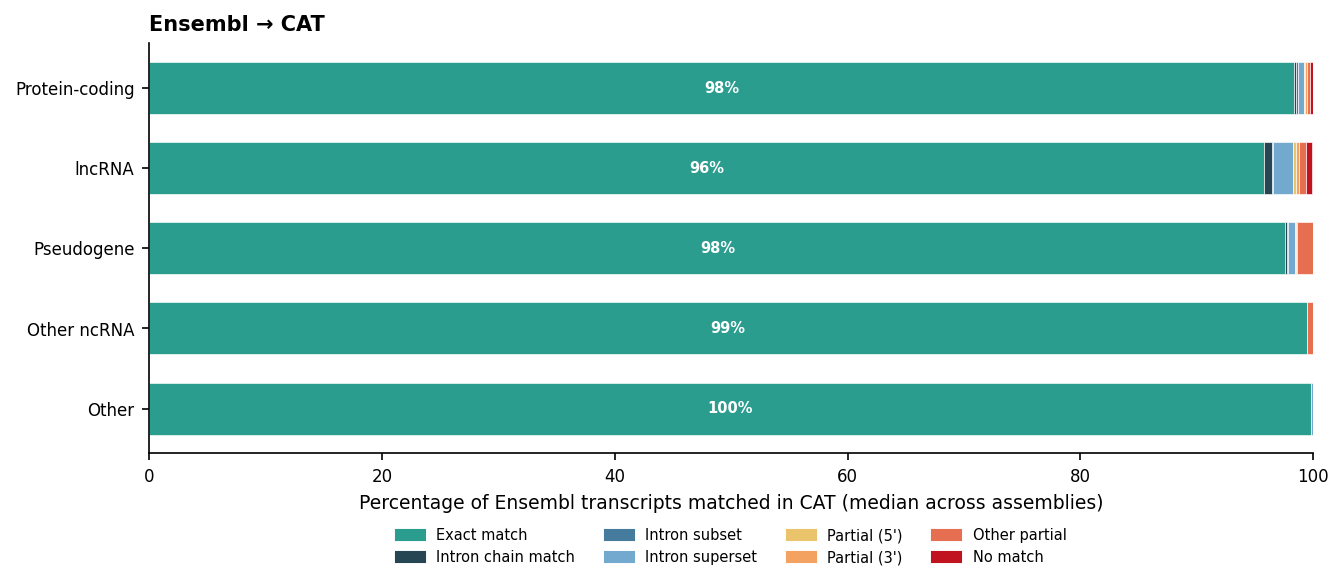

In [178]:
if not ic_data.empty:
    # ── B1: Full 8-class (Ensembl → CAT) ──────────────────────────────────
    fig, ax = plt.subplots(figsize=(9, 4))
    y_pos = np.arange(len(BIOTYPE_ORDER))
    left = np.zeros(len(BIOTYPE_ORDER))

    for cls in CLASSIFICATION_ORDER:
        v = medians_8[cls].values
        ax.barh(y_pos, v, left=left, height=0.65,
                color=CLASS_COLORS[cls], edgecolor='white', linewidth=0.3,
                label=CLASS_LABELS[cls])
        for j, (val, l) in enumerate(zip(v, left)):
            if val >= 5:
                ax.text(l + val/2, j, f'{val:.0f}%', ha='center', va='center',
                        fontsize=7, color='white', fontweight='bold')
        left += v

    ax.set_yticks(y_pos)
    ax.set_yticklabels([BIOTYPE_LABELS[b] for b in BIOTYPE_ORDER])
    ax.set_xlabel('Percentage of Ensembl transcripts matched in CAT (median across assemblies)')
    ax.set_title('Ensembl \u2192 CAT', fontsize=10, fontweight='bold', loc='left')
    ax.set_xlim(0, 100)
    ax.invert_yaxis()
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

    handles = [mpatches.Patch(color=CLASS_COLORS[c], label=CLASS_LABELS[c])
               for c in CLASSIFICATION_ORDER]
    ax.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, -0.15),
              ncol=4, fontsize=7, frameon=False)

    plt.tight_layout()
    save_panel(fig, 'panel_B1_intron_chain_8class')
    plt.show()

  Saved panel_B2_intron_chain_4group.{pdf,png}


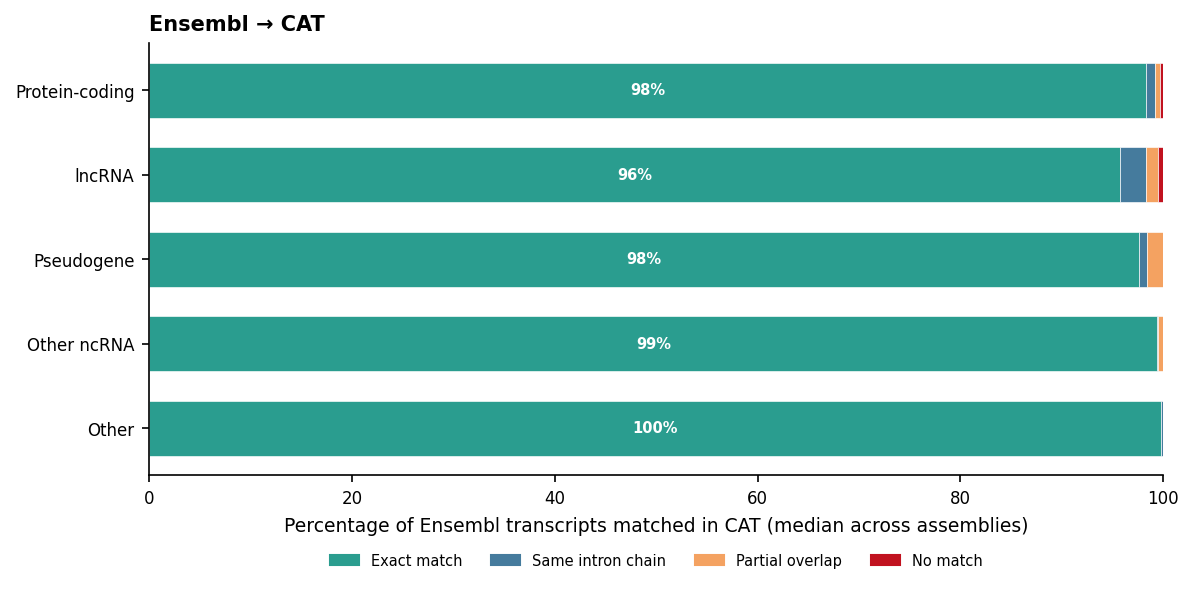

In [180]:
if not ic_data.empty:
    # ── B2: Collapsed 4-group (Ensembl → CAT) ─────────────────────────────
    fig, ax = plt.subplots(figsize=(8, 4))
    y_pos = np.arange(len(BIOTYPE_ORDER))
    left = np.zeros(len(BIOTYPE_ORDER))

    for grp in GROUP_4_ORDER:
        v = medians_4[grp].values
        ax.barh(y_pos, v, left=left, height=0.65,
                color=GROUP_4_COLORS[grp], edgecolor='white', linewidth=0.3,
                label=grp)
        for j, (val, l) in enumerate(zip(v, left)):
            if val >= 5:
                ax.text(l + val/2, j, f'{val:.0f}%', ha='center', va='center',
                        fontsize=7, color='white', fontweight='bold')
        left += v

    ax.set_yticks(y_pos)
    ax.set_yticklabels([BIOTYPE_LABELS[b] for b in BIOTYPE_ORDER])
    ax.set_xlabel('Percentage of Ensembl transcripts matched in CAT (median across assemblies)')
    ax.set_title('Ensembl \u2192 CAT', fontsize=10, fontweight='bold', loc='left')
    ax.set_xlim(0, 100)
    ax.invert_yaxis()
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

    handles = [mpatches.Patch(color=GROUP_4_COLORS[g], label=g) for g in GROUP_4_ORDER]
    ax.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, -0.15),
              ncol=4, fontsize=7, frameon=False)

    plt.tight_layout()
    save_panel(fig, 'panel_B2_intron_chain_4group')
    plt.show()

---
## Panel B_cat — CAT → Ensembl direction

This is the **reverse direction**: "what fraction of CAT transcripts can find
a match in the corresponding Ensembl gene?" Because CAT typically annotates
more transcripts per gene, the CAT→Ensembl direction reveals the 'extra'
CAT transcripts that have no Ensembl counterpart — these appear as No_Match.

  Saved panel_B1cat_intron_chain_8class.{pdf,png}


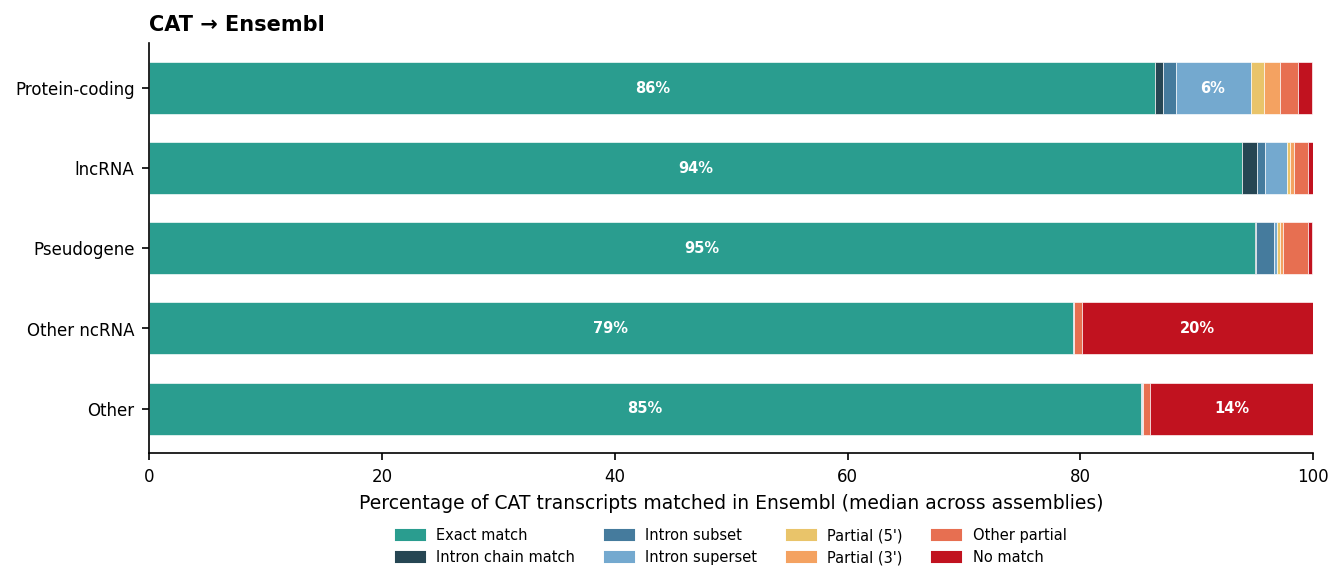

In [181]:
if not ic_data.empty and 'CAT_to_Ensembl' in medians_by_dir:
    # ── B1_cat: Full 8-class (CAT → Ensembl) ─────────────────────────────
    medians_8_cat = medians_by_dir['CAT_to_Ensembl']

    fig, ax = plt.subplots(figsize=(9, 4))
    y_pos = np.arange(len(BIOTYPE_ORDER))
    left = np.zeros(len(BIOTYPE_ORDER))

    for cls in CLASSIFICATION_ORDER:
        v = medians_8_cat[cls].values
        ax.barh(y_pos, v, left=left, height=0.65,
                color=CLASS_COLORS[cls], edgecolor='white', linewidth=0.3,
                label=CLASS_LABELS[cls])
        for j, (val, l) in enumerate(zip(v, left)):
            if val >= 5:
                ax.text(l + val/2, j, f'{val:.0f}%', ha='center', va='center',
                        fontsize=7, color='white', fontweight='bold')
        left += v

    ax.set_yticks(y_pos)
    ax.set_yticklabels([BIOTYPE_LABELS[b] for b in BIOTYPE_ORDER])
    ax.set_xlabel('Percentage of CAT transcripts matched in Ensembl (median across assemblies)')
    ax.set_title('CAT \u2192 Ensembl', fontsize=10, fontweight='bold', loc='left')
    ax.set_xlim(0, 100)
    ax.invert_yaxis()
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

    handles = [mpatches.Patch(color=CLASS_COLORS[c], label=CLASS_LABELS[c])
               for c in CLASSIFICATION_ORDER]
    ax.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, -0.15),
              ncol=4, fontsize=7, frameon=False)

    plt.tight_layout()
    save_panel(fig, 'panel_B1cat_intron_chain_8class')
    plt.show()
else:
    print('No CAT→Ensembl direction data available.')

  Saved panel_B_compare_directions.{pdf,png}


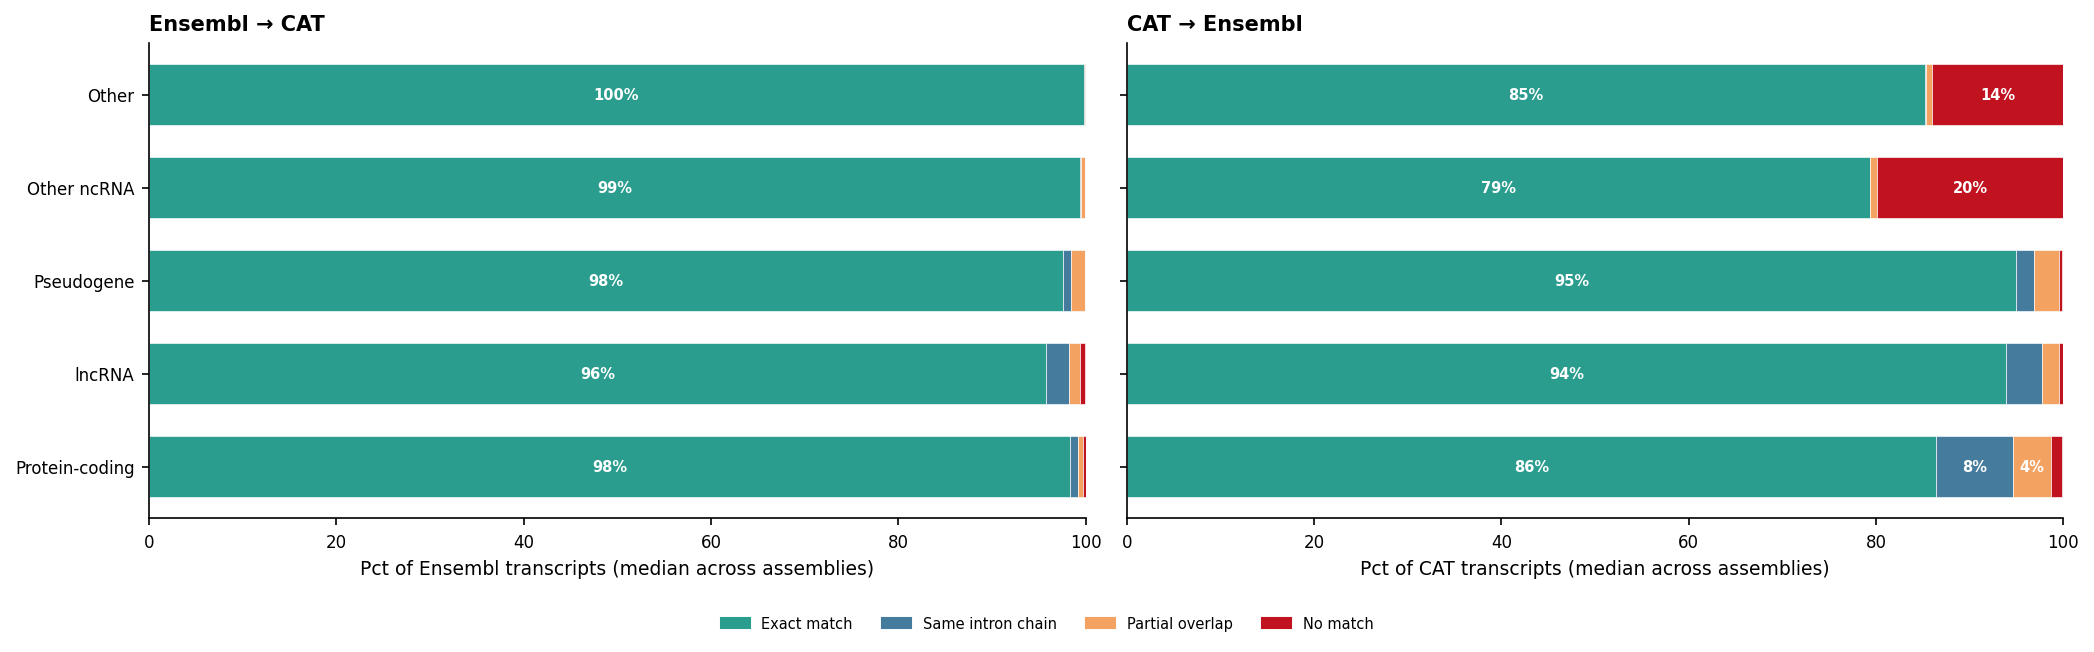

In [138]:
if not ic_data.empty and 'CAT_to_Ensembl' in medians_4_by_dir:
    # ── B_compare: Side-by-side 4-group comparison ────────────────────────
    # This is the key figure: shows that Ensembl→CAT looks ~98% exact,
    # but CAT→Ensembl reveals many extra CAT transcripts with no match.

    fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

    dir_configs = [
        ('Ensembl_to_CAT', 'Ensembl \u2192 CAT',
         'Pct of Ensembl transcripts'),
        ('CAT_to_Ensembl', 'CAT \u2192 Ensembl',
         'Pct of CAT transcripts'),
    ]

    for ax, (direction, title, xlabel) in zip(axes, dir_configs):
        med4 = medians_4_by_dir[direction]
        y_pos = np.arange(len(BIOTYPE_ORDER))
        left = np.zeros(len(BIOTYPE_ORDER))

        for grp in GROUP_4_ORDER:
            v = med4[grp].values
            ax.barh(y_pos, v, left=left, height=0.65,
                    color=GROUP_4_COLORS[grp], edgecolor='white', linewidth=0.3,
                    label=grp)
            for j, (val, l) in enumerate(zip(v, left)):
                if val >= 4:
                    ax.text(l + val/2, j, f'{val:.0f}%', ha='center', va='center',
                            fontsize=7, color='white', fontweight='bold')
            left += v

        ax.set_yticks(y_pos)
        ax.set_yticklabels([BIOTYPE_LABELS[b] for b in BIOTYPE_ORDER])
        ax.set_xlabel(f'{xlabel} (median across assemblies)')
        ax.set_title(title, fontsize=10, fontweight='bold', loc='left')
        ax.set_xlim(0, 100)
        ax.invert_yaxis()
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

    # Shared legend below
    handles = [mpatches.Patch(color=GROUP_4_COLORS[g], label=g) for g in GROUP_4_ORDER]
    fig.legend(handles=handles, loc='lower center',
               bbox_to_anchor=(0.5, -0.08), ncol=4, fontsize=7, frameon=False)

    plt.tight_layout()
    save_panel(fig, 'panel_B_compare_directions')
    plt.show()
else:
    print('Side-by-side comparison requires both directions.')

---
## Panel B_ratio — Transcript count ratio (CAT / Ensembl)

Shows how many more transcripts CAT annotates per gene compared to Ensembl.
A ratio > 1 means CAT predicts more transcripts. This explains why the
Ensembl→CAT direction shows high concordance (small set easily finds matches
in larger set) while CAT→Ensembl shows more discordance (extra CAT transcripts
have no Ensembl counterpart).

  Saved panel_B_ratio_data.tsv  (2310 rows)
  Saved panel_B_ratio.{pdf,png}


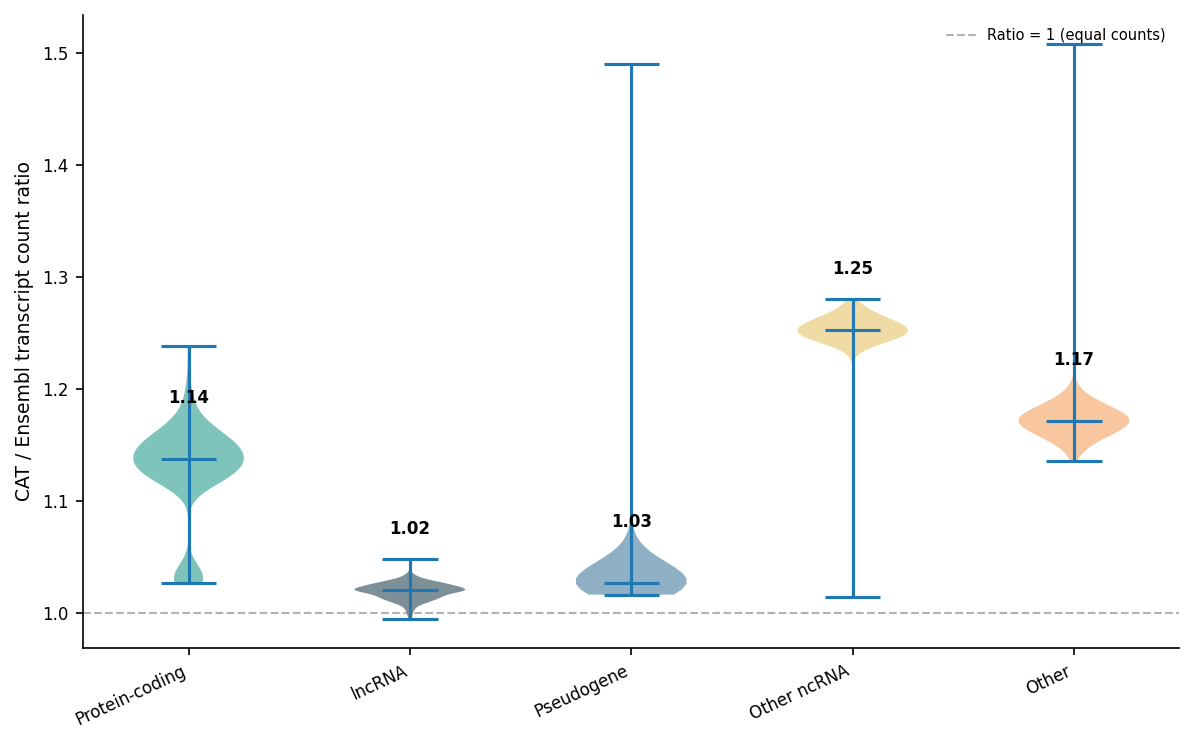

In [182]:
if not ratio_data.empty:
    # ── B_ratio: CAT/Ensembl transcript count ratio by biotype ────────
    save_data(ratio_data, 'panel_B_ratio')

    fig, ax = plt.subplots(figsize=(8, 5))

    bio_data, bio_labels_plot, bio_colors = [], [], []
    palette = {'protein_coding': '#2a9d8f', 'lncRNA': '#264653',
               'pseudogene': '#457b9d', 'other_ncRNA': '#e9c46a',
               'other': '#f4a261'}

    for bio in BIOTYPE_ORDER:
        bio_df = ratio_data[ratio_data['biotype'] == bio]
        if bio_df.empty:
            continue
        bio_data.append(bio_df['ratio_cat_to_ens'].values)
        bio_labels_plot.append(BIOTYPE_LABELS[bio])
        bio_colors.append(palette.get(bio, '#999999'))

    positions = np.arange(1, len(bio_data) + 1)
    parts = ax.violinplot(bio_data, positions=positions, showmedians=True)
    for pc, col in zip(parts['bodies'], bio_colors):
        pc.set_facecolor(col); pc.set_alpha(0.6)

    ax.set_xticks(positions)
    ax.set_xticklabels(bio_labels_plot, rotation=25, ha='right')
    ax.set_ylabel('CAT / Ensembl transcript count ratio')
    ax.axhline(1.0, color='grey', linewidth=1, linestyle='--', alpha=0.6,
               label='Ratio = 1 (equal counts)')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

    for i, d in enumerate(bio_data):
        m = np.median(d)
        ax.text(i + 1, m + 0.05, f'{m:.2f}', ha='center', fontsize=8,
                fontweight='bold')

    ax.legend(loc='upper right', fontsize=7, frameon=False)
    plt.tight_layout()
    save_panel(fig, 'panel_B_ratio')
    plt.show()
else:
    print('No transcript count ratio data available.')

---
## Panel B_supp — Full-denominator transcript concordance (supplementary)

Same as Panel B, but the denominator includes **all Ensembl transcripts**,
not just those from RBH-paired genes. Transcripts from Ensembl genes with
no CAT counterpart appear as "Gene not shared."

This shows the complete picture in one panel. Requires running both
`count_gff_transcripts.py` (on each assembly's Ensembl GFF) and
`aggregate_intron_chain_by_biotype.py --all-ensembl-genes-dir`.

Loaded full-denominator: 41,580 rows, 462 assemblies
  Saved panel_Bsupp_full_denom_data.tsv  (25 rows)

Full-denominator medians (% of ALL Ensembl transcripts):


group,Exact match,Same intron chain,Partial overlap,No match,Gene not shared
biotype,,,,,
protein_coding,178.4,8.7,4.4,1.5,6.8
lncRNA,174.9,5.9,2.8,0.9,15.3
pseudogene,181.0,2.6,4.0,0.3,12.1
other_ncRNA,165.2,0.1,1.1,17.0,16.4
other,164.8,0.3,0.5,11.0,23.2


  Saved panel_Bsupp_full_denom.{pdf,png}


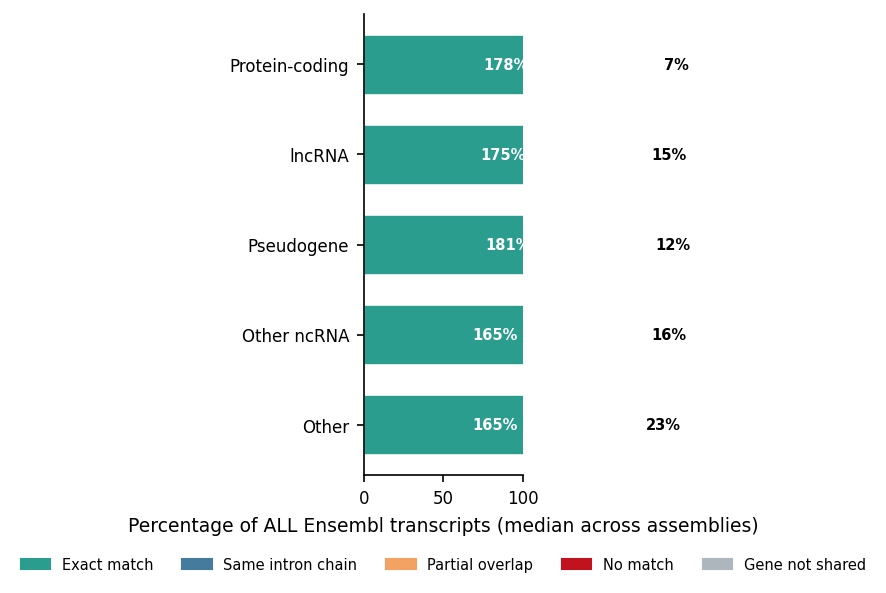

In [183]:
# ── Load full-denominator data (optional) ─────────────────────────────────
full_denom_file = INTRON_DIR / 'intron_chain_full_denom_per_assembly.tsv'
if full_denom_file.exists():
    fd_data = pd.read_csv(full_denom_file, sep='\t')
    print(f'Loaded full-denominator: {len(fd_data):,} rows, '
          f'{fd_data["assembly_accession"].nunique()} assemblies')
else:
    print(f'No full-denominator file — skipping Panel B_supp.')
    print(f'  To generate: run aggregate_intron_chain_by_biotype.py '
          f'with --all-ensembl-genes-dir')
    fd_data = pd.DataFrame()

if not fd_data.empty:
    # 5-group: same 4 groups + Gene_Not_Shared
    FULL_DENOM_GROUP_MAP = {
        'Exact_Match':     'Exact match',
        'Intron_Match':    'Same intron chain',
        'Intron_Subset':   'Same intron chain',
        'Intron_Superset': 'Same intron chain',
        'Partial_5':       'Partial overlap',
        'Partial_3':       'Partial overlap',
        'Other_Partial':   'Partial overlap',
        'No_Match':        'No match',
        'Gene_Not_Shared': 'Gene not shared',
    }
    GROUP_5_ORDER = ['Exact match', 'Same intron chain', 'Partial overlap',
                     'No match', 'Gene not shared']
    GROUP_5_COLORS = {
        'Exact match':       '#2a9d8f',
        'Same intron chain': '#457b9d',
        'Partial overlap':   '#f4a261',
        'No match':          '#c1121f',
        'Gene not shared':   '#adb5bd',
    }

    fd_data['group'] = fd_data['classification'].map(FULL_DENOM_GROUP_MAP)

    # Aggregate per assembly × biotype × group
    fd_grouped = (
        fd_data.groupby(['assembly_accession', 'biotype', 'group'])['pct']
        .sum()
        .reset_index()
    )

    # Median across assemblies
    fd_stats = (
        fd_grouped.groupby(['biotype', 'group'])['pct']
        .agg(median_pct='median', q25_pct=lambda x: x.quantile(0.25),
             q75_pct=lambda x: x.quantile(0.75))
        .reset_index()
    )
    save_data(fd_stats, 'panel_Bsupp_full_denom')

    fd_medians = (
        fd_stats.pivot(index='biotype', columns='group', values='median_pct')
        .reindex(index=BIOTYPE_ORDER, columns=GROUP_5_ORDER, fill_value=0)
    )

    print('\nFull-denominator medians (% of ALL Ensembl transcripts):')
    display(fd_medians.round(1))

    # ── Figure ────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(9, 4))
    y_pos = np.arange(len(BIOTYPE_ORDER))
    left = np.zeros(len(BIOTYPE_ORDER))

    for grp in GROUP_5_ORDER:
        v = fd_medians[grp].values
        ax.barh(y_pos, v, left=left, height=0.65,
                color=GROUP_5_COLORS[grp], edgecolor='white', linewidth=0.3,
                label=grp)
        for j, (val, l) in enumerate(zip(v, left)):
            if val >= 4:
                ax.text(l + val/2, j, f'{val:.0f}%', ha='center', va='center',
                        fontsize=7, color='white' if grp != 'Gene not shared' else 'black',
                        fontweight='bold')
        left += v

    ax.set_yticks(y_pos)
    ax.set_yticklabels([BIOTYPE_LABELS[b] for b in BIOTYPE_ORDER])
    ax.set_xlabel('Percentage of ALL Ensembl transcripts (median across assemblies)')
    ax.set_xlim(0, 100)
    ax.invert_yaxis()
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

    handles = [mpatches.Patch(color=GROUP_5_COLORS[g], label=g) for g in GROUP_5_ORDER]
    ax.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, -0.15),
              ncol=5, fontsize=7, frameon=False)

    plt.tight_layout()
    save_panel(fig, 'panel_Bsupp_full_denom')
    plt.show()

---
## Panel C — Jaccard index distribution by biotype

  Saved panel_C_jaccard_by_biotype_data.tsv  (2310 rows)
  Saved panel_C_jaccard_by_biotype.{pdf,png}


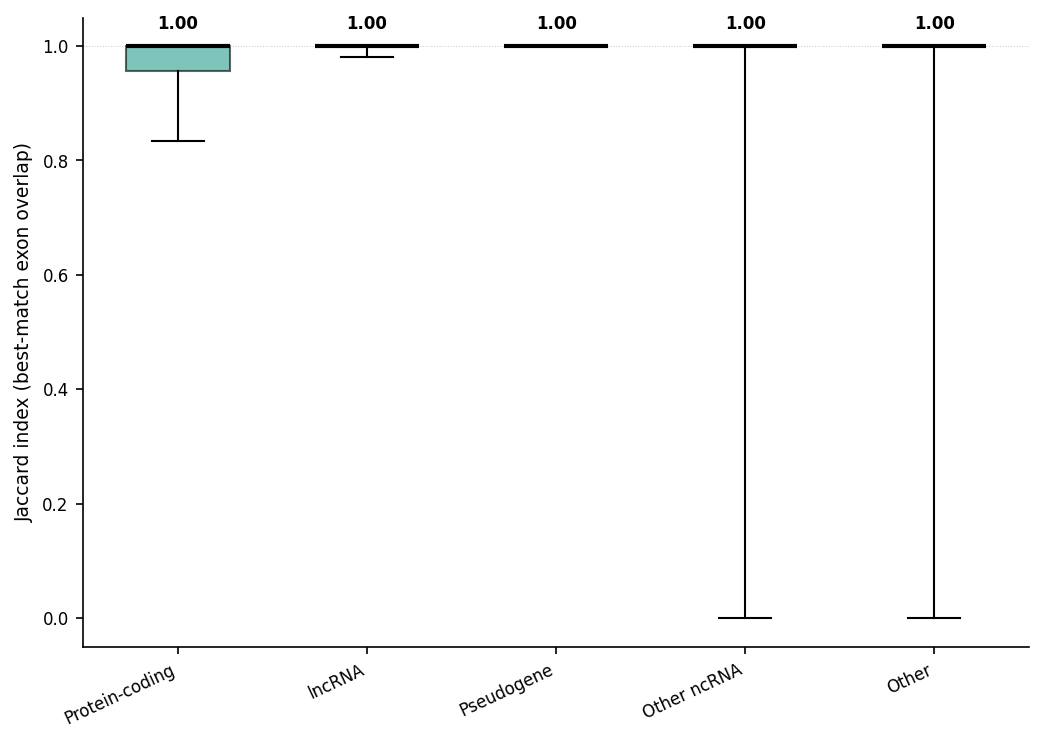

In [141]:
if jac_data.empty:
    print('Skipping Panel C — no Jaccard data.')
else:
    # ── Source data ────────────────────────────────────────────────────────
    save_data(jac_data, 'panel_C_jaccard_by_biotype')

    # ── Figure ────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(7, 5))

    bio_stats, bio_labels_plot = [], []
    for bio in BIOTYPE_ORDER:
        bio_df = jac_data[jac_data['biotype'] == bio]
        if bio_df.empty:
            continue
        bio_stats.append({
            'med':    float(bio_df['median'].median()),
            'q1':     float(bio_df['p25'].median()),
            'q3':     float(bio_df['p75'].median()),
            'whislo': float(bio_df['p5'].median()),
            'whishi': float(bio_df['p95'].median()),
            'fliers': [],
        })
        bio_labels_plot.append(BIOTYPE_LABELS[bio])

    positions = np.arange(1, len(bio_stats) + 1)
    bp = ax.bxp(bio_stats, positions=positions, widths=0.55,
                patch_artist=True, showfliers=False,
                medianprops=dict(color='black', linewidth=2))
    for patch in bp['boxes']:
        patch.set_facecolor('#2a9d8f'); patch.set_alpha(0.6)

    ax.set_xticks(positions)
    ax.set_xticklabels(bio_labels_plot, rotation=25, ha='right')
    ax.set_ylabel('Jaccard index (best-match exon overlap)')
    ax.set_ylim(-0.05, 1.05)
    ax.axhline(1.0, color='grey', linewidth=0.5, linestyle=':', alpha=0.4)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

    for i, stats in enumerate(bio_stats):
        ax.text(i + 1, stats['med'] + 0.03, f"{stats['med']:.2f}",
                ha='center', fontsize=8, fontweight='bold')

    plt.tight_layout()
    save_panel(fig, 'panel_C_jaccard_by_biotype')
    plt.show()

---
## Panel D — CDS concordance (protein-coding)

CDS columns: ['assembly_accession', 'sample_name', 'n_coding_pairs', 'n_has_both_cds', 'n_start_match', 'n_stop_match', 'n_frame_intact', 'n_full_match', 'pct_start_match', 'pct_stop_match', 'pct_frame_intact', 'pct_full_match']
Using: pct_full_match
  Saved panel_D_cds_concordance_data.tsv  (462 rows)
  Saved panel_D_cds_concordance.{pdf,png}


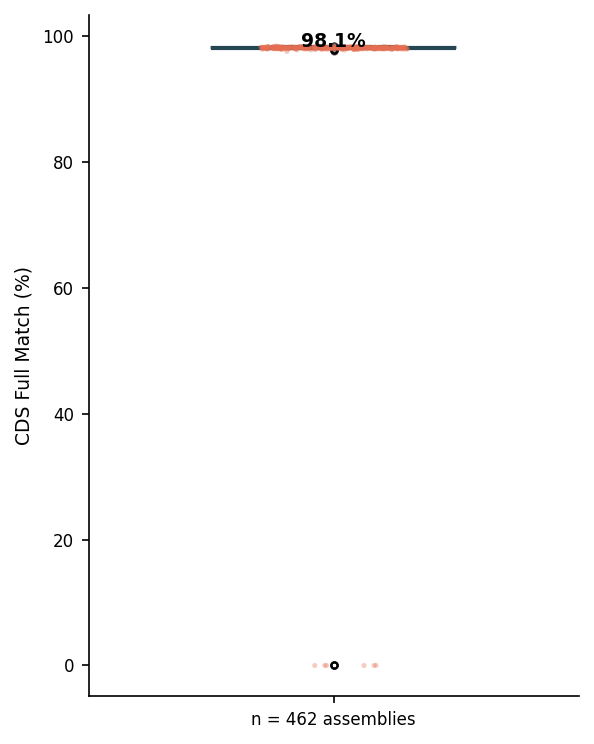

In [142]:
if cds_asm.empty:
    print('Skipping Panel D — no CDS data.')
else:
    # Find the full-match column
    pct_col = None
    for candidate in ['pct_Full_Match', 'pct_full_match', 'full_match_pct']:
        if candidate in cds_asm.columns:
            pct_col = candidate
            break
    print(f'CDS columns: {list(cds_asm.columns)}')
    print(f'Using: {pct_col}')

    if pct_col:
        # ── Source data ────────────────────────────────────────────────────
        cds_export = cds_asm[['assembly_accession', pct_col]].copy()
        cds_export = cds_export.rename(columns={pct_col: 'pct_cds_full_match'})
        save_data(cds_export, 'panel_D_cds_concordance')

        cds_vals = cds_asm[pct_col].dropna()
        cds_med = cds_vals.median()

        # ── Figure ────────────────────────────────────────────────────────
        fig, ax = plt.subplots(figsize=(4, 5))
        ax.boxplot(cds_vals, vert=True, widths=0.5, patch_artist=True,
                   boxprops=dict(facecolor='#e76f51', alpha=0.3),
                   medianprops=dict(color='#264653', linewidth=2),
                   whiskerprops=dict(color='#264653'),
                   capprops=dict(color='#264653'),
                   flierprops=dict(marker='o', markersize=3, alpha=0.5))
        jitter = np.random.default_rng(42).uniform(-0.15, 0.15, len(cds_vals))
        ax.scatter(np.ones(len(cds_vals)) + jitter, cds_vals, s=6, alpha=0.35,
                   color='#e76f51', edgecolors='none', zorder=3)
        ax.set_ylabel('CDS Full Match (%)')
        ax.set_xticks([1]); ax.set_xticklabels([f'n = {len(cds_vals)} assemblies'])
        ax.text(1, cds_med + 0.15, f'{cds_med:.1f}%', ha='center', fontsize=9, fontweight='bold')
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

        plt.tight_layout()
        save_panel(fig, 'panel_D_cds_concordance')
        plt.show()
    else:
        print(f'Could not find full-match column. Available: {list(cds_asm.columns)}')

---
## Panel E — GRCh38 divergence categories

  Saved panel_E_divergence_data.tsv  (458 rows)
  Saved panel_E_divergence.{pdf,png}


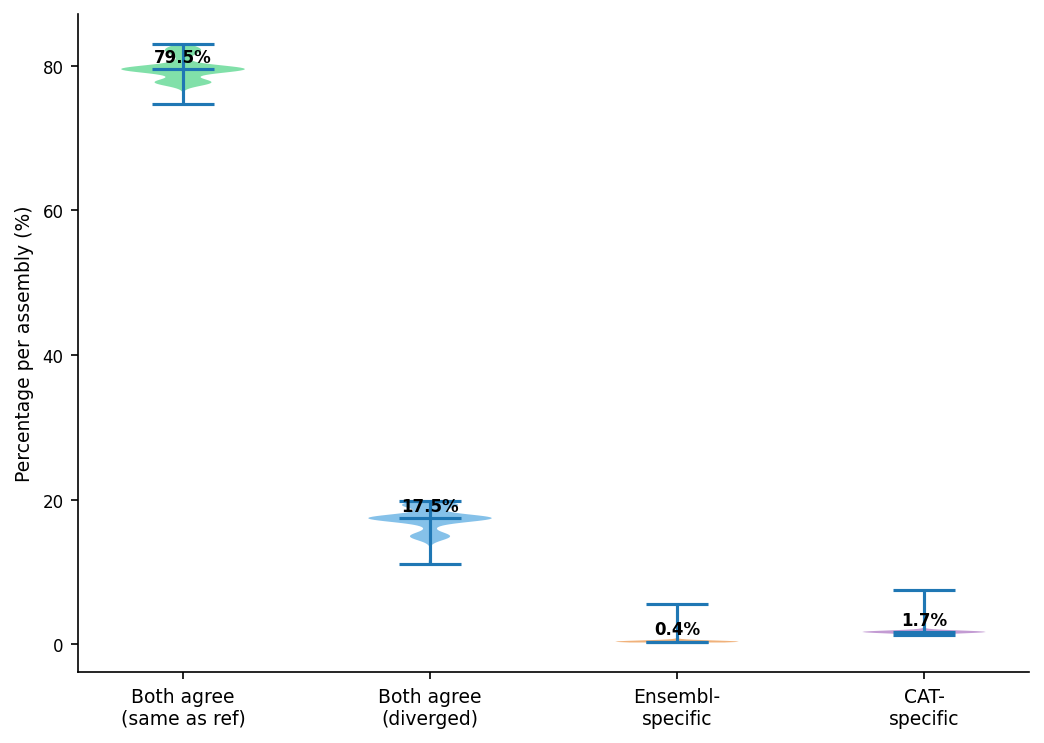

In [184]:
DIV_COLS   = ['pct_both_agree_reference', 'pct_both_agree_diverged',
              'pct_ensembl_specific', 'pct_cat_specific']
DIV_LABELS = ['Both agree\n(same as ref)', 'Both agree\n(diverged)',
              'Ensembl-\nspecific', 'CAT-\nspecific']
DIV_COLORS = ['#2ecc71', '#3498db', '#e67e22', '#9b59b6']

if div_asm.empty:
    print('Skipping Panel E — no divergence data.')
else:
    present_cols = [c for c in DIV_COLS if c in div_asm.columns]
    if not present_cols:
        print(f'No divergence columns found. Available: {list(div_asm.columns)[:8]}')
    else:
        # ── Source data ────────────────────────────────────────────────────
        div_export = div_asm[['assembly_accession'] + present_cols].copy()
        save_data(div_export, 'panel_E_divergence')

        # ── Figure ────────────────────────────────────────────────────────
        fig, ax = plt.subplots(figsize=(7, 5))
        data = [div_asm[c].dropna().values for c in present_cols]
        labels = [DIV_LABELS[DIV_COLS.index(c)] for c in present_cols]
        colors = [DIV_COLORS[DIV_COLS.index(c)] for c in present_cols]

        parts = ax.violinplot(data, showmedians=True)
        for i, (pc, col) in enumerate(zip(parts['bodies'], colors)):
            pc.set_facecolor(col); pc.set_alpha(0.6)

        ax.set_xticks(range(1, len(labels) + 1))
        ax.set_xticklabels(labels, fontsize=9)
        ax.set_ylabel('Percentage per assembly (%)')
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

        for i, d in enumerate(data):
            m = np.median(d)
            ax.text(i + 1, m + 1, f'{m:.1f}%', ha='center', fontsize=8, fontweight='bold')

        plt.tight_layout()
        save_panel(fig, 'panel_E_divergence')
        plt.show()

---
## Summary statistics for manuscript text

In [144]:
print('=' * 60)
print('KEY NUMBERS FOR MANUSCRIPT TEXT')
print('=' * 60)

vals = gene_pres['pct'].dropna()
print(f'\nGene-level agreement:')
print(f'  Median: {vals.median():.1f}%  '
      f'(IQR: {vals.quantile(0.25):.1f}\u2013{vals.quantile(0.75):.1f}%)')
print(f'  Range:  {vals.min():.1f}\u2013{vals.max():.1f}%')
print(f'  N assemblies: {len(vals)}')

if not ic_data.empty:
    for direction, label in [('Ensembl_to_CAT', 'Ensembl \u2192 CAT'),
                              ('CAT_to_Ensembl', 'CAT \u2192 Ensembl')]:
        if direction not in medians_by_dir:
            continue
        m8 = medians_by_dir[direction]
        print(f'\nTranscript concordance \u2014 {label} (median % across assemblies):')
        for bio in BIOTYPE_ORDER:
            if bio in m8.index:
                exact = m8.loc[bio, 'Exact_Match']
                same_chain = (exact + m8.loc[bio, 'Intron_Match']
                              + m8.loc[bio, 'Intron_Subset']
                              + m8.loc[bio, 'Intron_Superset'])
                no_match = m8.loc[bio, 'No_Match']
                print(f'  {BIOTYPE_LABELS[bio]:20s}: '
                      f'Exact={exact:.1f}%, Same chain={same_chain:.1f}%, '
                      f'No match={no_match:.1f}%')

if not ratio_data.empty:
    print(f'\nTranscript count ratio (CAT / Ensembl, median across assemblies):')
    for bio in BIOTYPE_ORDER:
        bio_df = ratio_data[ratio_data['biotype'] == bio]
        if not bio_df.empty:
            r = bio_df['ratio_cat_to_ens'].median()
            n_ens = bio_df['n_ensembl_tx'].median()
            n_cat = bio_df['n_cat_tx'].median()
            print(f'  {BIOTYPE_LABELS[bio]:20s}: '
                  f'ratio={r:.2f}  '
                  f'(median {int(n_cat):,} CAT / {int(n_ens):,} Ensembl tx)')

if not jac_data.empty:
    print(f'\nJaccard index (median-of-medians across assemblies, per gene):')
    for bio in BIOTYPE_ORDER:
        bio_df = jac_data[jac_data['biotype'] == bio]
        if not bio_df.empty:
            print(f'  {BIOTYPE_LABELS[bio]:20s}: '
                  f'median={bio_df["median"].median():.3f}, '
                  f'IQR={bio_df["p25"].median():.3f}\u2013{bio_df["p75"].median():.3f}')

if not cds_asm.empty and pct_col:
    cv = cds_asm[pct_col].dropna()
    print(f'\nCDS concordance (protein-coding):')
    print(f'  Median: {cv.median():.1f}%  '
          f'(IQR: {cv.quantile(0.25):.1f}\u2013{cv.quantile(0.75):.1f}%)')

print(f'\n{"=" * 60}')
print('Output files written to:', FIGURE_DIR)
print('Done.')

KEY NUMBERS FOR MANUSCRIPT TEXT

Gene-level agreement:
  Median: 97.5%  (IQR: 97.1–97.8%)
  Range:  94.8–98.7%
  N assemblies: 462

Transcript concordance — Ensembl → CAT (median % across assemblies):
  Protein-coding      : Exact=98.3%, Same chain=99.2%, No match=0.3%
  lncRNA              : Exact=95.8%, Same chain=98.3%, No match=0.5%
  Pseudogene          : Exact=97.6%, Same chain=98.4%, No match=0.0%
  Other ncRNA         : Exact=99.4%, Same chain=99.5%, No match=0.0%
  Other               : Exact=99.8%, Same chain=100.0%, No match=0.0%

Transcript concordance — CAT → Ensembl (median % across assemblies):
  Protein-coding      : Exact=86.4%, Same chain=94.6%, No match=1.2%
  lncRNA              : Exact=93.9%, Same chain=97.7%, No match=0.5%
  Pseudogene          : Exact=95.0%, Same chain=96.9%, No match=0.3%
  Other ncRNA         : Exact=79.3%, Same chain=79.4%, No match=19.8%
  Other               : Exact=85.2%, Same chain=85.4%, No match=14.0%

Transcript count ratio (CAT / Ensem

---## Addendum — Denominator‑Sensitive Global Views and Rug OverlaysThis addendum adds non‑breaking panels at the end of the notebook:- Rug‑overlay variants of Panel B (4‑group), exposing per‑assembly spread while retaining median stacks.- Global, transcript‑weighted 4‑group stacks for both directions (paired‑genes denominator) — a cohort‑pooled view.- Global, transcript‑weighted 5‑group stacks for the full‑denominator Ensembl→CAT view (adds Gene not shared), when available.Each panel writes a matching `_data.tsv` with exactly the plotted values.

In [145]:

# Helpers for rug overlays and pooled views
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Add rung dots for 4-group distributions (per-assembly) behind bars
# ic_df must have columns: assembly_accession, direction, biotype, classification, pct

def add_rung_dots_4group(ax, ic_df, direction, biotype_order, group4_map, group4_colors,
                         y_positions, group_order=None, y_offsets=None, alpha=0.18, size=6, seed=42):
    rng = np.random.default_rng(seed)
    group_order = group_order or ['Exact match','Same intron chain','Partial overlap','No match']
    y_offsets = y_offsets or {
        'Exact match':       -0.24,
        'Same intron chain': -0.08,
        'Partial overlap':    0.08,
        'No match':           0.24,
    }

    df = ic_df[ic_df['direction'] == direction].copy()
    if df.empty:
        return
    df['group'] = df['classification'].map(group4_map)

    # Collapse 8-class pct to per-assembly 4-group pct (sum within assembly×biotype)
    asm = (df.groupby(['assembly_accession','biotype','group'])['pct']
             .sum().reset_index())

    for j, bio in enumerate(biotype_order):
        bio_df = asm[asm['biotype'] == bio]
        for g in group_order:
            vals = bio_df[bio_df['group'] == g]['pct'].to_numpy()
            if vals.size == 0:
                continue
            yj = y_positions[j] + y_offsets[g] + rng.uniform(-0.03, 0.03, size=vals.size)
            ax.scatter(vals, yj, s=size, alpha=alpha, color=group4_colors[g],
                       edgecolors='none', zorder=1)

# Build tidy dataset with per-assembly 4-group pct and median lines (for _data.tsv)

def build_rug_dataset_4group(ic_df, direction, biotype_order, group4_map, group_order):
    df = ic_df[ic_df['direction'] == direction].copy()
    if df.empty:
        return pd.DataFrame()
    df['group'] = df['classification'].map(group4_map)
    asm = (df.groupby(['assembly_accession','biotype','group'])['pct']
             .sum().reset_index().rename(columns={'pct':'value'}))
    asm['kind'] = 'assembly'
    # medians per biotype×group across assemblies
    med = (asm.groupby(['biotype','group'])['value']
             .median().reset_index())
    med['assembly_accession'] = ''
    med['kind'] = 'median'
    out = pd.concat([asm[['assembly_accession','biotype','group','value','kind']],
                     med[['assembly_accession','biotype','group','value','kind']]], ignore_index=True)
    # ensure biotype order
    out['biotype'] = pd.Categorical(out['biotype'], categories=biotype_order, ordered=True)
    out['group'] = pd.Categorical(out['group'], categories=group_order, ordered=True)
    out['direction'] = direction
    return out.sort_values(['kind','biotype','group','assembly_accession'])

# Pooled 4-group (transcript-weighted) for a direction
# Uses n_transcripts to sum across assemblies, then percent within biotype

def pooled_4group(ic_df, direction, biotype_order, group4_map, group_order):
    df = ic_df[ic_df['direction'] == direction].copy()
    if df.empty:
        return pd.DataFrame(), pd.DataFrame()
    df['group'] = df['classification'].map(group4_map)
    pooled = (df.groupby(['biotype','group'])['n_transcripts']
                .sum().reset_index(name='n'))
    totals = pooled.groupby('biotype')['n'].transform('sum')
    pooled['pct'] = 100 * pooled['n'] / totals
    wide = (pooled.pivot(index='biotype', columns='group', values='pct')
                  .reindex(index=biotype_order, columns=group_order, fill_value=0))
    wide_counts = (pooled.pivot(index='biotype', columns='group', values='n')
                          .reindex(index=biotype_order, columns=group_order, fill_value=0))
    return wide, wide_counts

# Utility: safe palette for 5-group full-denominator
FULL_DENOM_GROUP_MAP = {
    'Exact_Match':     'Exact match',
    'Intron_Match':    'Same intron chain',
    'Intron_Subset':   'Same intron chain',
    'Intron_Superset': 'Same intron chain',
    'Partial_5':       'Partial overlap',
    'Partial_3':       'Partial overlap',
    'Other_Partial':   'Partial overlap',
    'No_Match':        'No match',
    'Gene_Not_Shared': 'Gene not shared',
}
GROUP_5_ORDER = ['Exact match','Same intron chain','Partial overlap','No match','Gene not shared']
GROUP_5_COLORS = {
    'Exact match':       '#2a9d8f',
    'Same intron chain': '#457b9d',
    'Partial overlap':   '#f4a261',
    'No match':          '#c1121f',
    'Gene not shared':   '#adb5bd',
}


### Panel B2 (rug overlay) — Ensembl → CAT, 4‑group with per‑assembly rugsDenominator: transcripts from paired genes only. Bars are medians across assemblies; semi‑transparent dots are per‑assembly 4‑group percentages (collapsed from 8‑class within each assembly).

  Saved panel_B2_intron_chain_4group_rugs_data.tsv  (9260 rows)
  Saved panel_B2_intron_chain_4group_rugs.{pdf,png}


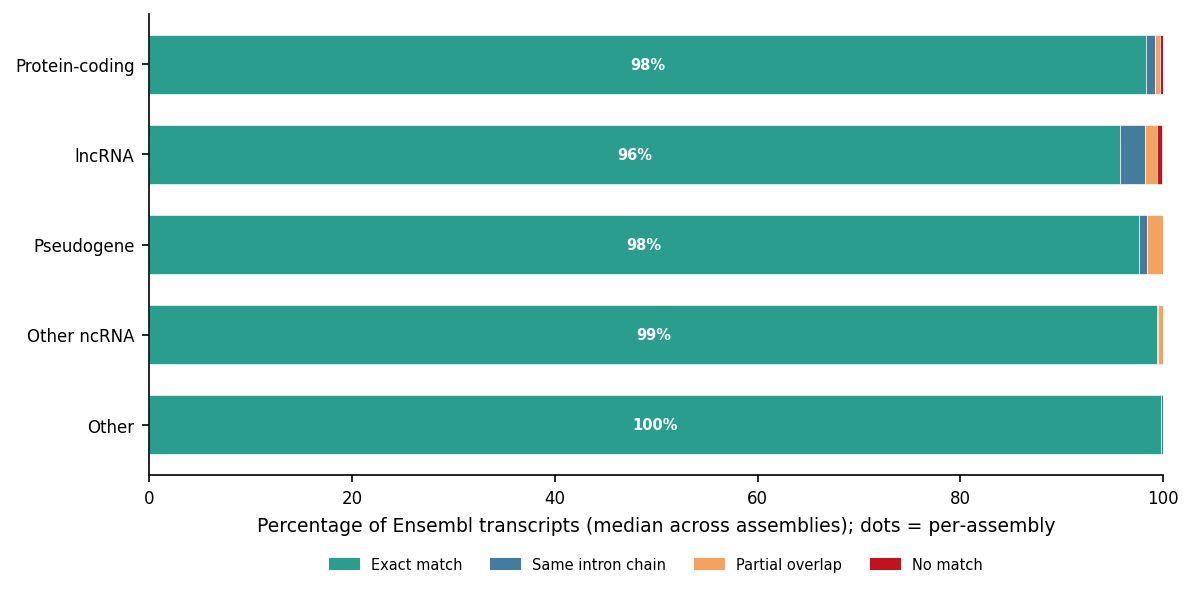

In [146]:

if not ic_data.empty:
    direction = 'Ensembl_to_CAT'
    # Ensure medians_4 exists
    if 'medians_4_by_dir' not in globals():
        # Recompute medians_4_by_dir if needed
        stats_by_dir = {}
        for d in ['Ensembl_to_CAT','CAT_to_Ensembl']:
            dir_data = ic_data[ic_data['direction']==d]
            if dir_data.empty: 
                continue
            stats = (dir_data.groupby(['biotype','classification'])['pct']
                              .agg(median_pct='median', q25_pct=lambda x: x.quantile(0.25),
                                   q75_pct=lambda x: x.quantile(0.75))
                              .reset_index())
            stats_by_dir[d] = stats
        medians_4_by_dir = {}
        for d, stats in stats_by_dir.items():
            stats_4 = stats.copy(); stats_4['group'] = stats_4['classification'].map(GROUP_4_MAP)
            stats_4_agg = (stats_4.groupby(['biotype','group'])
                                   .agg(median_pct=('median_pct','sum'))
                                   .reset_index())
            medians_4_by_dir[d] = (stats_4_agg.pivot(index='biotype', columns='group', values='median_pct')
                                            .reindex(index=BIOTYPE_ORDER, columns=GROUP_4_ORDER, fill_value=0))
    med4 = medians_4_by_dir.get(direction)

    # Build dataset for export (assemblies + medians)
    rug_df = build_rug_dataset_4group(ic_data, direction, BIOTYPE_ORDER, GROUP_4_MAP, GROUP_4_ORDER)
    if not rug_df.empty:
        save_data(rug_df.assign(direction=direction), 'panel_B2_intron_chain_4group_rugs')

    fig, ax = plt.subplots(figsize=(8, 4))
    y_pos = np.arange(len(BIOTYPE_ORDER))

    # rugs first
    add_rung_dots_4group(ax, ic_data, direction, BIOTYPE_ORDER, GROUP_4_MAP, GROUP_4_COLORS,
                         y_pos, group_order=GROUP_4_ORDER)

    # median stacks
    left = np.zeros(len(BIOTYPE_ORDER))
    for grp in GROUP_4_ORDER:
        v = med4[grp].values if med4 is not None else np.zeros(len(BIOTYPE_ORDER))
        ax.barh(y_pos, v, left=left, height=0.65,
                color=GROUP_4_COLORS[grp], edgecolor='white', linewidth=0.3, zorder=2,
                label=grp)
        for j, (val, l) in enumerate(zip(v, left)):
            if val >= 5:
                ax.text(l + val/2, j, f'{val:.0f}%', ha='center', va='center', fontsize=7, color='white', fontweight='bold')
        left += v

    ax.set_yticks(y_pos)
    ax.set_yticklabels([BIOTYPE_LABELS[b] for b in BIOTYPE_ORDER])
    ax.set_xlabel('Percentage of Ensembl transcripts (median across assemblies); dots = per‑assembly')
    ax.set_xlim(0,100); ax.invert_yaxis(); ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    handles = [mpatches.Patch(color=GROUP_4_COLORS[g], label=g) for g in GROUP_4_ORDER]
    ax.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=4, fontsize=7, frameon=False)
    plt.tight_layout(); save_panel(fig, 'panel_B2_intron_chain_4group_rugs'); plt.show()
else:
    print('Skipping B2 rugs — no intron chain data.')


### Panel B_compare (rug overlay) — Both directions, 4‑group with per‑assembly rugsDenominators: transcripts from paired genes only. Each subplot shows median stacks and underlying per‑assembly dots.

  Saved panel_B_compare_directions_rugs.{pdf,png}


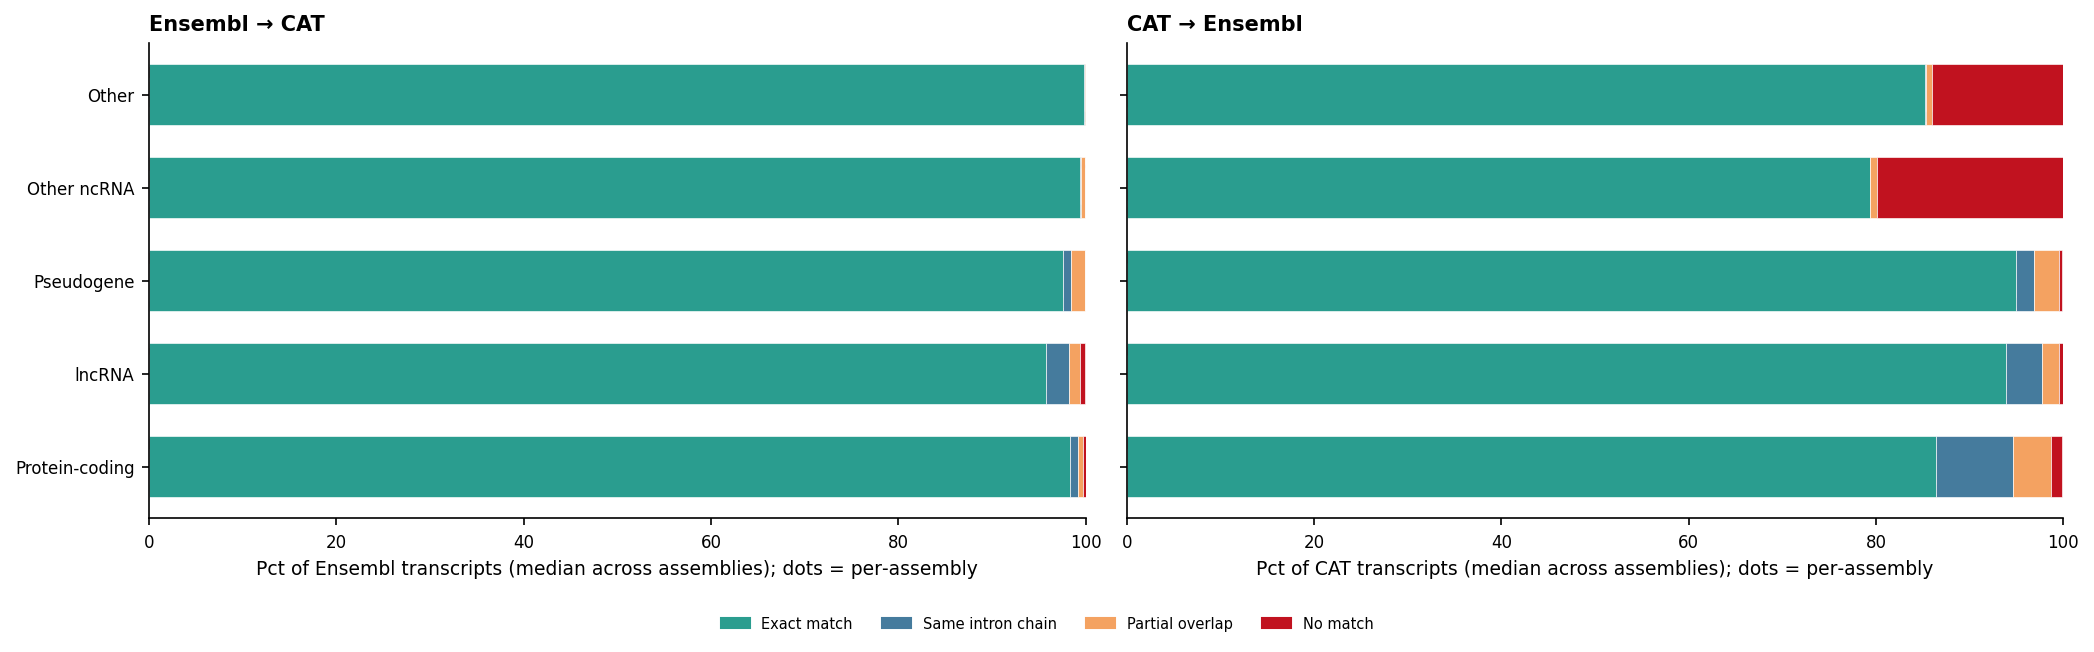

In [147]:

if not ic_data.empty and 'medians_4_by_dir' in globals() and 'CAT_to_Ensembl' in medians_4_by_dir:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
    configs = [
        ('Ensembl_to_CAT', 'Ensembl → CAT', 'Pct of Ensembl transcripts'),
        ('CAT_to_Ensembl', 'CAT → Ensembl', 'Pct of CAT transcripts'),
    ]

    for ax, (direction, title, xlabel) in zip(axes, configs):
        med4 = medians_4_by_dir.get(direction)
        y_pos = np.arange(len(BIOTYPE_ORDER))
        # rugs
        add_rung_dots_4group(ax, ic_data, direction, BIOTYPE_ORDER, GROUP_4_MAP, GROUP_4_COLORS,
                             y_pos, group_order=GROUP_4_ORDER)
        # bars
        left = np.zeros(len(BIOTYPE_ORDER))
        for grp in GROUP_4_ORDER:
            v = med4[grp].values if med4 is not None else np.zeros(len(BIOTYPE_ORDER))
            ax.barh(y_pos, v, left=left, height=0.65,
                    color=GROUP_4_COLORS[grp], edgecolor='white', linewidth=0.3, zorder=2)
            left += v
        ax.set_yticks(y_pos); ax.set_yticklabels([BIOTYPE_LABELS[b] for b in BIOTYPE_ORDER])
        ax.set_xlabel(f'{xlabel} (median across assemblies); dots = per‑assembly')
        ax.set_title(title, fontsize=10, fontweight='bold', loc='left')
        ax.set_xlim(0,100); ax.invert_yaxis(); ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

    handles = [mpatches.Patch(color=GROUP_4_COLORS[g], label=g) for g in GROUP_4_ORDER]
    fig.legend(handles=handles, loc='lower center', bbox_to_anchor=(0.5, -0.08), ncol=4, fontsize=7, frameon=False)
    plt.tight_layout(); save_panel(fig, 'panel_B_compare_directions_rugs'); plt.show()
else:
    print('Skipping B_compare rugs — need both directions and medians_4_by_dir.')


### Global (pooled) 4‑group — Transcript‑weighted, paired‑genes denominatorWe pool `n_transcripts` across all assemblies per biotype×group×direction, then compute within‑biotype percentages. This avoids median‑across‑assemblies bias and reflects the cohort’s transcript composition.

  Saved panel_B_global_pooled_4group_data.tsv  (40 rows)
  Saved panel_B_global_pooled_4group.{pdf,png}


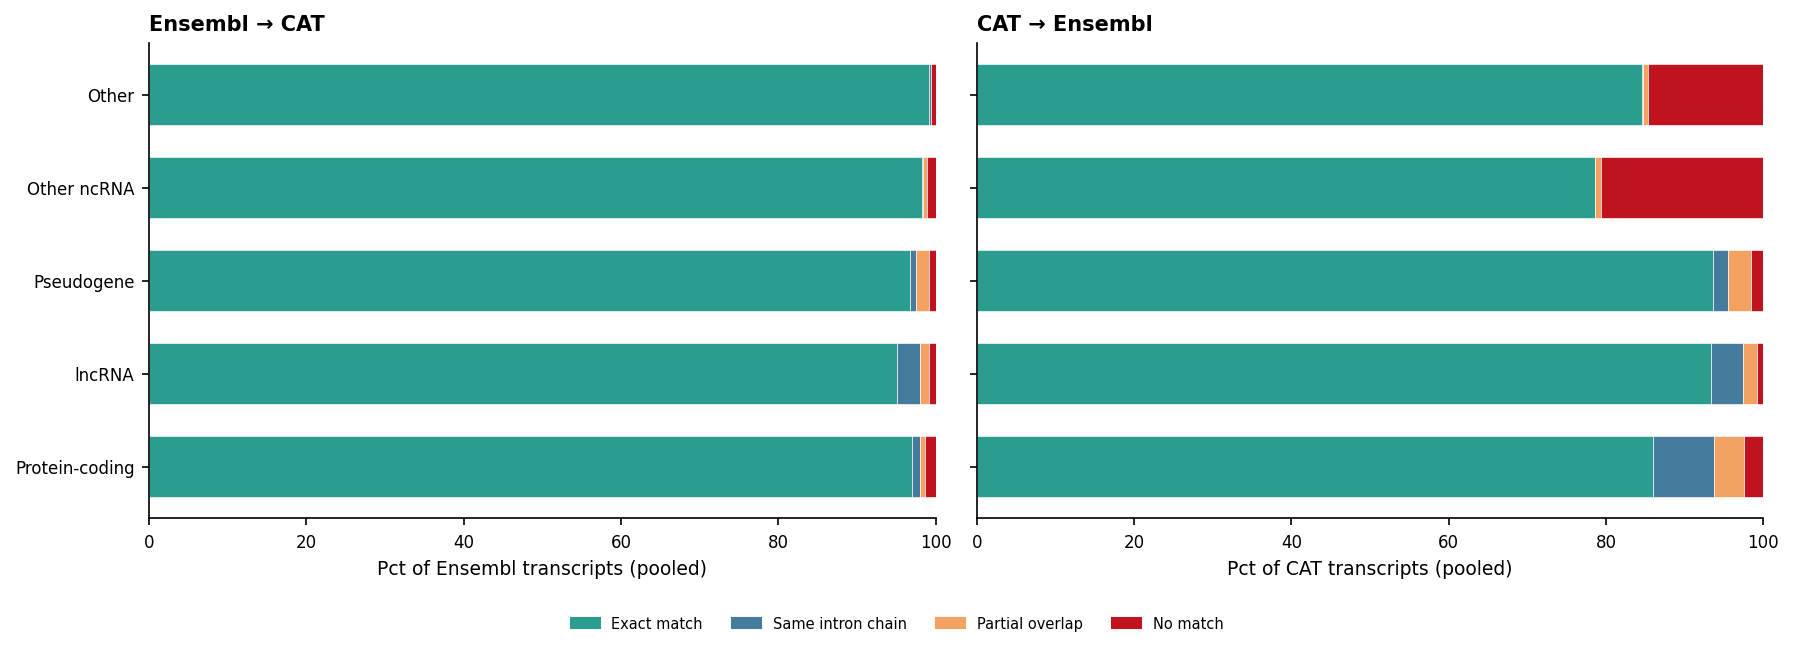

In [148]:

if not ic_data.empty:
    med4_ens, counts_ens = pooled_4group(ic_data, 'Ensembl_to_CAT', BIOTYPE_ORDER, GROUP_4_MAP, GROUP_4_ORDER)
    med4_cat, counts_cat = pooled_4group(ic_data, 'CAT_to_Ensembl', BIOTYPE_ORDER, GROUP_4_MAP, GROUP_4_ORDER)

    # Export tidy source data
    def to_tidy(med4, counts, direction):
        if med4 is None or isinstance(med4, pd.DataFrame) and med4.empty:
            return pd.DataFrame()
        m = med4.reset_index().melt(id_vars='biotype', var_name='group', value_name='pct')
        c = counts.reset_index().melt(id_vars='biotype', var_name='group', value_name='n_transcripts')
        t = m.merge(c, on=['biotype','group'], how='left')
        t['direction'] = direction
        return t
    tidy = []
    tidy.append(to_tidy(med4_ens, counts_ens, 'Ensembl_to_CAT'))
    tidy.append(to_tidy(med4_cat, counts_cat, 'CAT_to_Ensembl'))
    tidy = pd.concat([x for x in tidy if x is not None and not x.empty], ignore_index=True) if len(tidy)>0 else pd.DataFrame()
    if not tidy.empty:
        save_data(tidy, 'panel_B_global_pooled_4group')

    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
    plots = [
        (axes[0], med4_ens, 'Ensembl → CAT', 'Pct of Ensembl transcripts (pooled)'),
        (axes[1], med4_cat, 'CAT → Ensembl', 'Pct of CAT transcripts (pooled)'),
    ]
    for ax, med4, title, xlabel in plots:
        y_pos = np.arange(len(BIOTYPE_ORDER))
        left = np.zeros(len(BIOTYPE_ORDER))
        if med4 is None or med4.empty:
            continue
        for grp in GROUP_4_ORDER:
            v = med4[grp].values
            ax.barh(y_pos, v, left=left, height=0.65,
                    color=GROUP_4_COLORS[grp], edgecolor='white', linewidth=0.3, zorder=2)
            left += v
        ax.set_yticks(y_pos); ax.set_yticklabels([BIOTYPE_LABELS[b] for b in BIOTYPE_ORDER])
        ax.set_xlim(0,100); ax.invert_yaxis(); ax.set_title(title, fontsize=10, fontweight='bold', loc='left')
        ax.set_xlabel(xlabel); ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    handles = [mpatches.Patch(color=GROUP_4_COLORS[g], label=g) for g in GROUP_4_ORDER]
    fig.legend(handles=handles, loc='lower center', bbox_to_anchor=(0.5, -0.08), ncol=4, fontsize=7, frameon=False)
    plt.tight_layout(); save_panel(fig, 'panel_B_global_pooled_4group'); plt.show()
else:
    print('Skipping global pooled 4-group — no intron chain data.')


  Saved panel_B_global_pooled_4group_cohort_data.tsv  (8 rows)
  Saved panel_B_global_pooled_4group_cohort.{pdf,png}


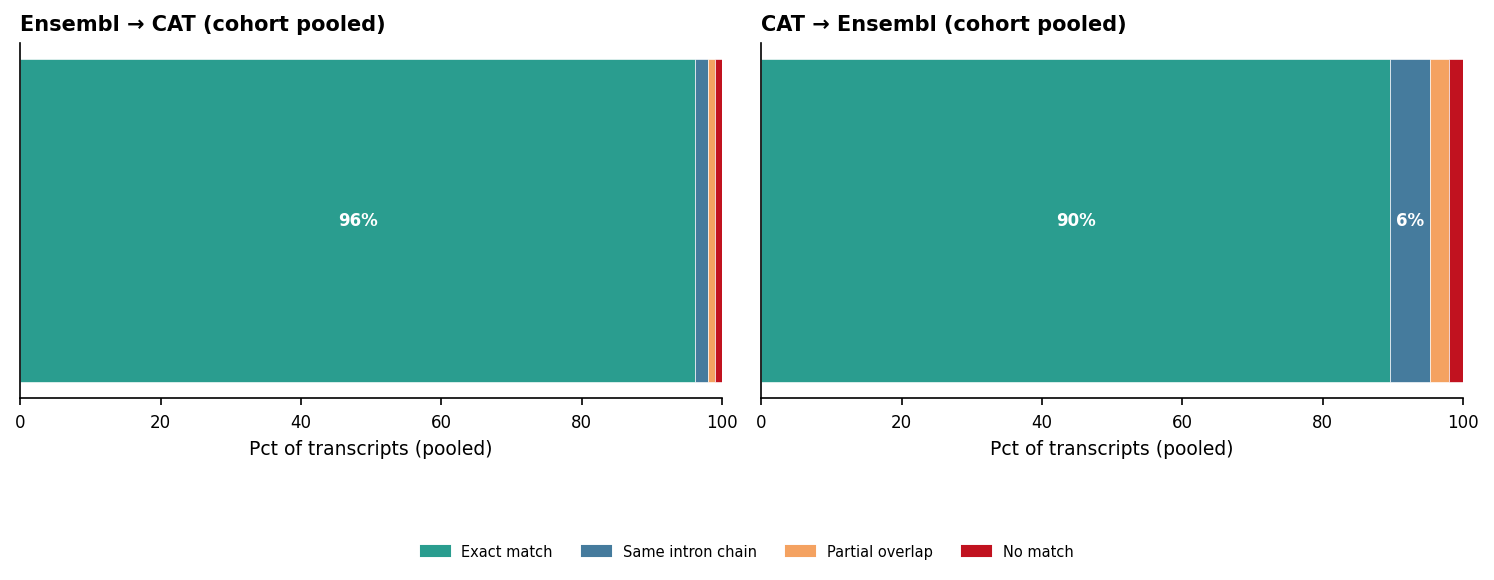

In [149]:

if not ic_data.empty:
    def cohort_pooled_4group(ic_df, direction):
        df = ic_df[ic_df['direction']==direction].copy()
        if df.empty:
            return pd.Series(dtype=float)
        df['group'] = df['classification'].map(GROUP_4_MAP)
        pooled = df.groupby(['group'])['n_transcripts'].sum()
        total = pooled.sum()
        return 100 * pooled / total if total>0 else pooled

    s_ens = cohort_pooled_4group(ic_data, 'Ensembl_to_CAT')
    s_cat = cohort_pooled_4group(ic_data, 'CAT_to_Ensembl')

    tidy = (pd.concat([
                s_ens.rename('pct').reset_index().assign(direction='Ensembl_to_CAT'),
                s_cat.rename('pct').reset_index().assign(direction='CAT_to_Ensembl')
            ], ignore_index=True)
            if (s_ens is not None and not s_ens.empty) or (s_cat is not None and not s_cat.empty)
            else pd.DataFrame())
    if not tidy.empty:
        save_data(tidy, 'panel_B_global_pooled_4group_cohort')

    fig, axes = plt.subplots(1, 2, figsize=(10, 3.2), sharey=True)
    for ax, series, title in [
        (axes[0], s_ens, 'Ensembl → CAT (cohort pooled)'),
        (axes[1], s_cat, 'CAT → Ensembl (cohort pooled)'),
    ]:
        if series is None or series.empty:
            continue
        left = 0.0
        for g in GROUP_4_ORDER:
            val = float(series.get(g, 0.0))
            ax.barh([0], [val], left=[left], height=0.5,
                    color=GROUP_4_COLORS[g], edgecolor='white', linewidth=0.3)
            if val >= 5:
                ax.text(left + val/2, 0, f'{val:.0f}%', ha='center', va='center', fontsize=8, color='white', fontweight='bold')
            left += val
        ax.set_yticks([]); ax.set_xlim(0,100); ax.set_xlabel('Pct of transcripts (pooled)')
        ax.set_title(title, fontsize=10, fontweight='bold', loc='left')
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    handles = [mpatches.Patch(color=GROUP_4_COLORS[g], label=g) for g in GROUP_4_ORDER]
    fig.legend(handles=handles, loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=4, fontsize=7, frameon=False)
    plt.tight_layout(); save_panel(fig, 'panel_B_global_pooled_4group_cohort'); plt.show()
else:
    print('Skipping cohort pooled 4-group — no intron chain data.')


### Global (pooled) 5‑group — Transcript‑weighted, full denominator (Ensembl → CAT)Includes transcripts from Ensembl genes with no CAT pair as “Gene not shared.” This is the conservative coverage view; only available if `intron_chain_full_denom_per_assembly.tsv` was generated.

Loaded full-denominator (global pooled): 41,580 rows, 462 assemblies
  Saved panel_B_global_pooled_5group_full_denom_data.tsv  (25 rows)
  Saved panel_B_global_pooled_5group_full_denom.{pdf,png}


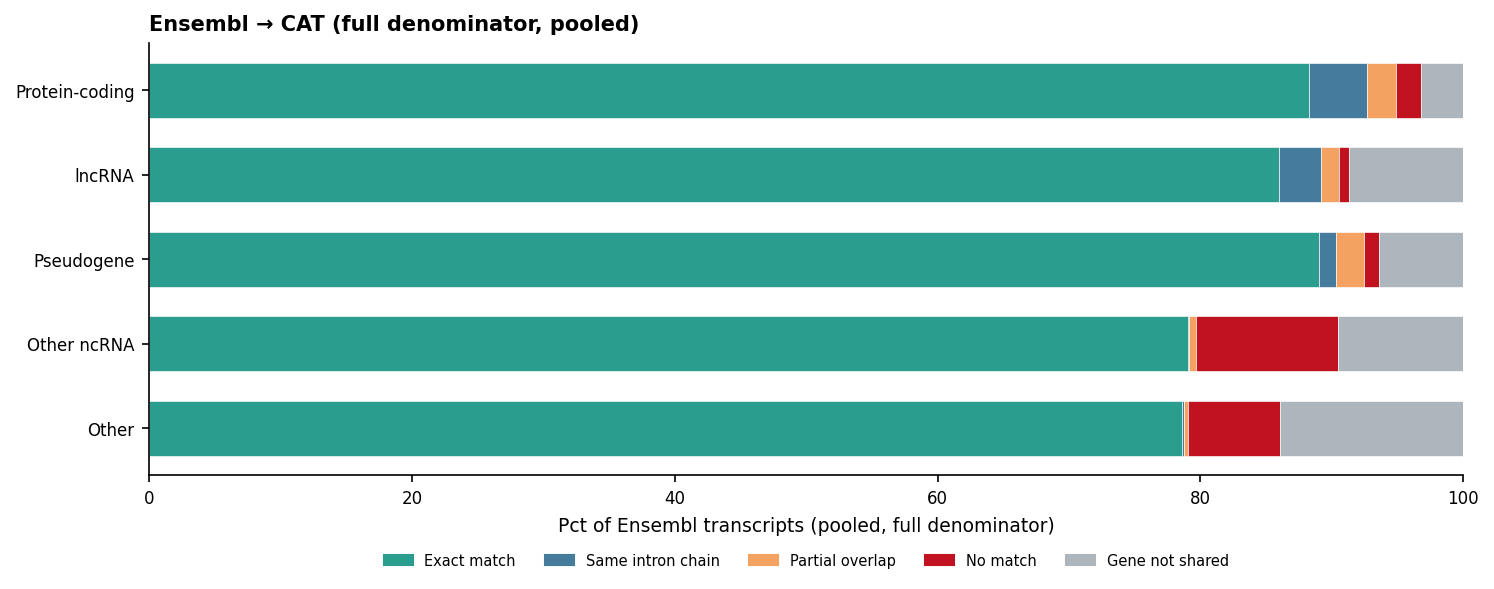

In [150]:

# Load full-denominator data if not already loaded in earlier cell
full_denom_file = INTRON_DIR / 'intron_chain_full_denom_per_assembly.tsv'
if full_denom_file.exists():
    fd_data2 = pd.read_csv(full_denom_file, sep='	')
    print(f'Loaded full-denominator (global pooled): {len(fd_data2):,} rows, {fd_data2["assembly_accession"].nunique()} assemblies')
else:
    fd_data2 = pd.DataFrame()
    print('No full-denominator file found — skipping global pooled 5-group.')

if not fd_data2.empty:
    df = fd_data2.copy()
    df['group'] = df['classification'].map(FULL_DENOM_GROUP_MAP)
    # Pooled counts across assemblies per biotype×group
    pooled = (df.groupby(['biotype','group'])['n_transcripts']
                .sum().reset_index(name='n'))
    totals = pooled.groupby('biotype')['n'].transform('sum')
    pooled['pct'] = 100 * pooled['n'] / totals
    wide = (pooled.pivot(index='biotype', columns='group', values='pct')
                  .reindex(index=BIOTYPE_ORDER, columns=GROUP_5_ORDER, fill_value=0))

    # Export tidy source data
    tidy = pooled.rename(columns={'n':'n_transcripts'})
    save_data(tidy, 'panel_B_global_pooled_5group_full_denom')

    fig, ax = plt.subplots(figsize=(10, 4))
    y_pos = np.arange(len(BIOTYPE_ORDER))
    left = np.zeros(len(BIOTYPE_ORDER))
    for grp in GROUP_5_ORDER:
        v = wide[grp].values
        ax.barh(y_pos, v, left=left, height=0.65,
                color=GROUP_5_COLORS[grp], edgecolor='white', linewidth=0.3)
        left += v
    ax.set_yticks(y_pos); ax.set_yticklabels([BIOTYPE_LABELS[b] for b in BIOTYPE_ORDER])
    ax.set_xlim(0,100); ax.invert_yaxis(); ax.set_xlabel('Pct of Ensembl transcripts (pooled, full denominator)')
    ax.set_title('Ensembl → CAT (full denominator, pooled)', fontsize=10, fontweight='bold', loc='left')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    handles = [mpatches.Patch(color=GROUP_5_COLORS[g], label=g) for g in GROUP_5_ORDER]
    ax.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=5, fontsize=7, frameon=False)
    plt.tight_layout(); save_panel(fig, 'panel_B_global_pooled_5group_full_denom'); plt.show()


  Saved panel_B_global_pooled_5group_full_denom_cohort_data.tsv  (5 rows)
  Saved panel_B_global_pooled_5group_full_denom_cohort.{pdf,png}


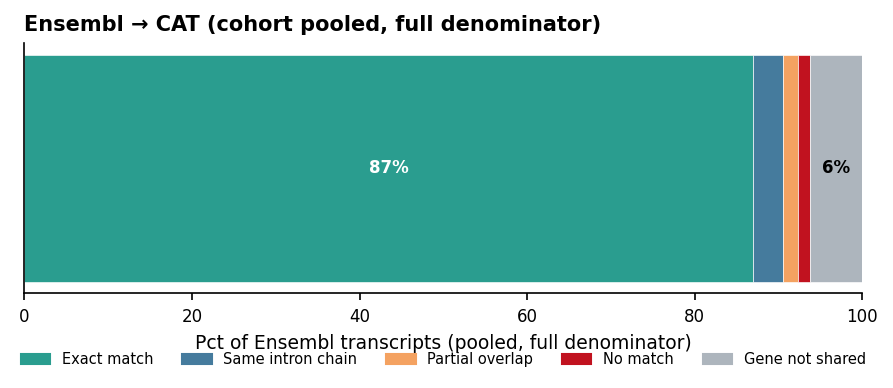

In [151]:

if not fd_data2.empty:
    s = (fd_data2.assign(group=lambda x: x['classification'].map(FULL_DENOM_GROUP_MAP))
                     .groupby('group')['n_transcripts'].sum())
    total = s.sum()
    pct = 100 * s / total if total>0 else s
    tidy = pct.rename('pct').reset_index()
    save_data(tidy, 'panel_B_global_pooled_5group_full_denom_cohort')

    fig, ax = plt.subplots(figsize=(6.5, 2.8))
    left = 0.0
    for g in GROUP_5_ORDER:
        val = float(pct.get(g, 0.0))
        ax.barh([0], [val], left=[left], height=0.5,
                color=GROUP_5_COLORS[g], edgecolor='white', linewidth=0.3)
        if val >= 5:
            ax.text(left + val/2, 0, f'{val:.0f}%', ha='center', va='center', fontsize=8, color='white' if g!='Gene not shared' else 'black', fontweight='bold')
        left += val
    ax.set_yticks([]); ax.set_xlim(0,100); ax.set_xlabel('Pct of Ensembl transcripts (pooled, full denominator)')
    ax.set_title('Ensembl → CAT (cohort pooled, full denominator)', fontsize=10, fontweight='bold', loc='left')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    handles = [mpatches.Patch(color=GROUP_5_COLORS[g], label=g) for g in GROUP_5_ORDER]
    ax.legend(handles=handles, loc='lower center', bbox_to_anchor=(0.5, -0.35), ncol=5, fontsize=7, frameon=False)
    plt.tight_layout(); save_panel(fig, 'panel_B_global_pooled_5group_full_denom_cohort'); plt.show()


### Side‑by‑side: Full‑denominator Ensembl → CAT vs reverse direction (medians)Left: Ensembl→CAT, full denominator (5 groups, includes “Gene not shared”) — median % across assemblies per biotype.Right: CAT→Ensembl, paired‑genes denominator (4 groups) — median % across assemblies per biotype.This juxtaposes coverage‑aware Ensembl→CAT with the reverse‑direction matchability of CAT transcripts.

  Saved panel_B_full_denom_vs_reverse_medians_data.tsv  (45 rows)
  Saved panel_B_full_denom_vs_reverse_medians.{pdf,png}


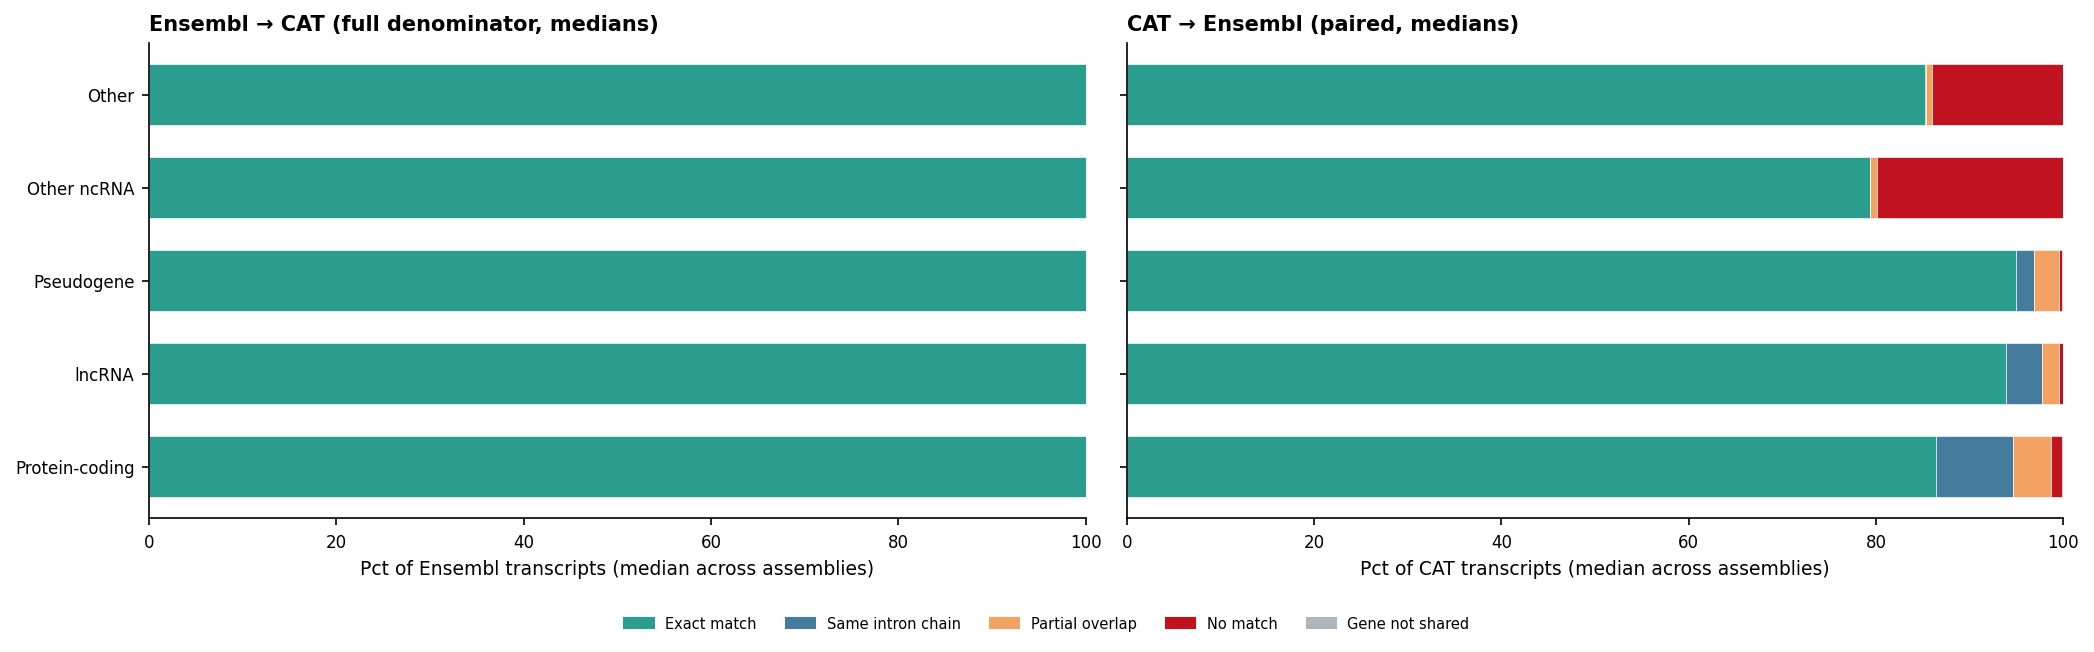

In [152]:

# Compute 5-group medians for full denominator (left) and 4-group medians for CAT→Ensembl (right)
from collections import OrderedDict

# Load full-denominator raw if not already
full_denom_file = INTRON_DIR / 'intron_chain_full_denom_per_assembly.tsv'
if 'fd_data2' not in globals():
    if full_denom_file.exists():
        fd_data2 = pd.read_csv(full_denom_file, sep='	')
        print(f'Loaded full-denominator (side-by-side medians): {len(fd_data2):,} rows, {fd_data2["assembly_accession"].nunique()} assemblies')
    else:
        fd_data2 = pd.DataFrame()

# Build 5-group medians (across assemblies)
fd_med5 = pd.DataFrame()
if not fd_data2.empty:
    fd_tmp = fd_data2.copy()
    fd_tmp['group'] = fd_tmp['classification'].map(FULL_DENOM_GROUP_MAP)
    fd_grouped = (fd_tmp.groupby(['assembly_accession','biotype','group'])['pct']
                        .sum().reset_index())
    fd_med5 = (fd_grouped.groupby(['biotype','group'])['pct']
                         .median().reset_index())
    fd_med5 = (fd_med5.pivot(index='biotype', columns='group', values='pct')
                      .reindex(index=BIOTYPE_ORDER, columns=GROUP_5_ORDER, fill_value=0))

# Build 4-group medians for CAT→Ensembl
med4_cat = pd.DataFrame()
if not ic_data.empty:
    dir_data = ic_data[ic_data['direction'] == 'CAT_to_Ensembl']
    if not dir_data.empty:
        stats = (dir_data.groupby(['biotype','classification'])['pct']
                          .agg(median_pct='median', q25_pct=lambda x: x.quantile(0.25),
                               q75_pct=lambda x: x.quantile(0.75))
                          .reset_index())
        stats['group'] = stats['classification'].map(GROUP_4_MAP)
        stats4 = (stats.groupby(['biotype','group'])['median_pct'].sum().reset_index())
        med4_cat = (stats4.pivot(index='biotype', columns='group', values='median_pct')
                           .reindex(index=BIOTYPE_ORDER, columns=GROUP_4_ORDER, fill_value=0))

if fd_med5.empty or med4_cat.empty:
    print('Skipping side-by-side medians — need full-denominator data and CAT→Ensembl medians.')
else:
    # Export tidy source data
    left_tidy = (fd_med5.reset_index().melt(id_vars='biotype', var_name='group', value_name='pct')
                           .assign(side='Ensembl_to_CAT_full_denom', denom='full', stat='median'))
    right_tidy = (med4_cat.reset_index().melt(id_vars='biotype', var_name='group', value_name='pct')
                            .assign(side='CAT_to_Ensembl_paired', denom='paired', stat='median'))
    combined = pd.concat([left_tidy, right_tidy], ignore_index=True)
    save_data(combined, 'panel_B_full_denom_vs_reverse_medians')

    fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

    # Left: full denominator 5-group
    ax = axes[0]
    y_pos = np.arange(len(BIOTYPE_ORDER))
    left = np.zeros(len(BIOTYPE_ORDER))
    for grp in GROUP_5_ORDER:
        v = fd_med5[grp].values
        ax.barh(y_pos, v, left=left, height=0.65,
                color=GROUP_5_COLORS[grp], edgecolor='white', linewidth=0.3)
        left += v
    ax.set_yticks(y_pos); ax.set_yticklabels([BIOTYPE_LABELS[b] for b in BIOTYPE_ORDER])
    ax.set_xlim(0,100); ax.invert_yaxis(); ax.set_title('Ensembl → CAT (full denominator, medians)', fontsize=10, fontweight='bold', loc='left')
    ax.set_xlabel('Pct of Ensembl transcripts (median across assemblies)')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

    # Right: CAT→Ensembl 4-group
    ax = axes[1]
    left = np.zeros(len(BIOTYPE_ORDER))
    for grp in GROUP_4_ORDER:
        v = med4_cat[grp].values
        ax.barh(y_pos, v, left=left, height=0.65,
                color=GROUP_4_COLORS[grp], edgecolor='white', linewidth=0.3)
        left += v
    ax.set_yticks(y_pos); ax.set_yticklabels([BIOTYPE_LABELS[b] for b in BIOTYPE_ORDER])
    ax.set_xlim(0,100); ax.invert_yaxis(); ax.set_title('CAT → Ensembl (paired, medians)', fontsize=10, fontweight='bold', loc='left')
    ax.set_xlabel('Pct of CAT transcripts (median across assemblies)')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

    # Combined legend (includes Gene not shared)
    used = OrderedDict()
    for g in GROUP_5_ORDER:
        used[g] = GROUP_5_COLORS[g]
    for g in GROUP_4_ORDER:
        used.setdefault(g, GROUP_4_COLORS[g])
    handles = [mpatches.Patch(color=c, label=g) for g, c in used.items()]
    fig.legend(handles=handles, loc='lower center', bbox_to_anchor=(0.5, -0.08), ncol=5, fontsize=7, frameon=False)

    plt.tight_layout(); save_panel(fig, 'panel_B_full_denom_vs_reverse_medians'); plt.show()


### Side‑by‑side (rugs): Full‑denominator Ensembl → CAT vs CAT → EnsemblAdds per‑assembly rug dots behind both subplots. Left uses 5 groups (full denominator); right uses 4 groups (paired genes).

  Saved panel_B_full_denom_vs_reverse_medians_rugs_data.tsv  (20835 rows)
  Saved panel_B_full_denom_vs_reverse_medians_rugs.{pdf,png}


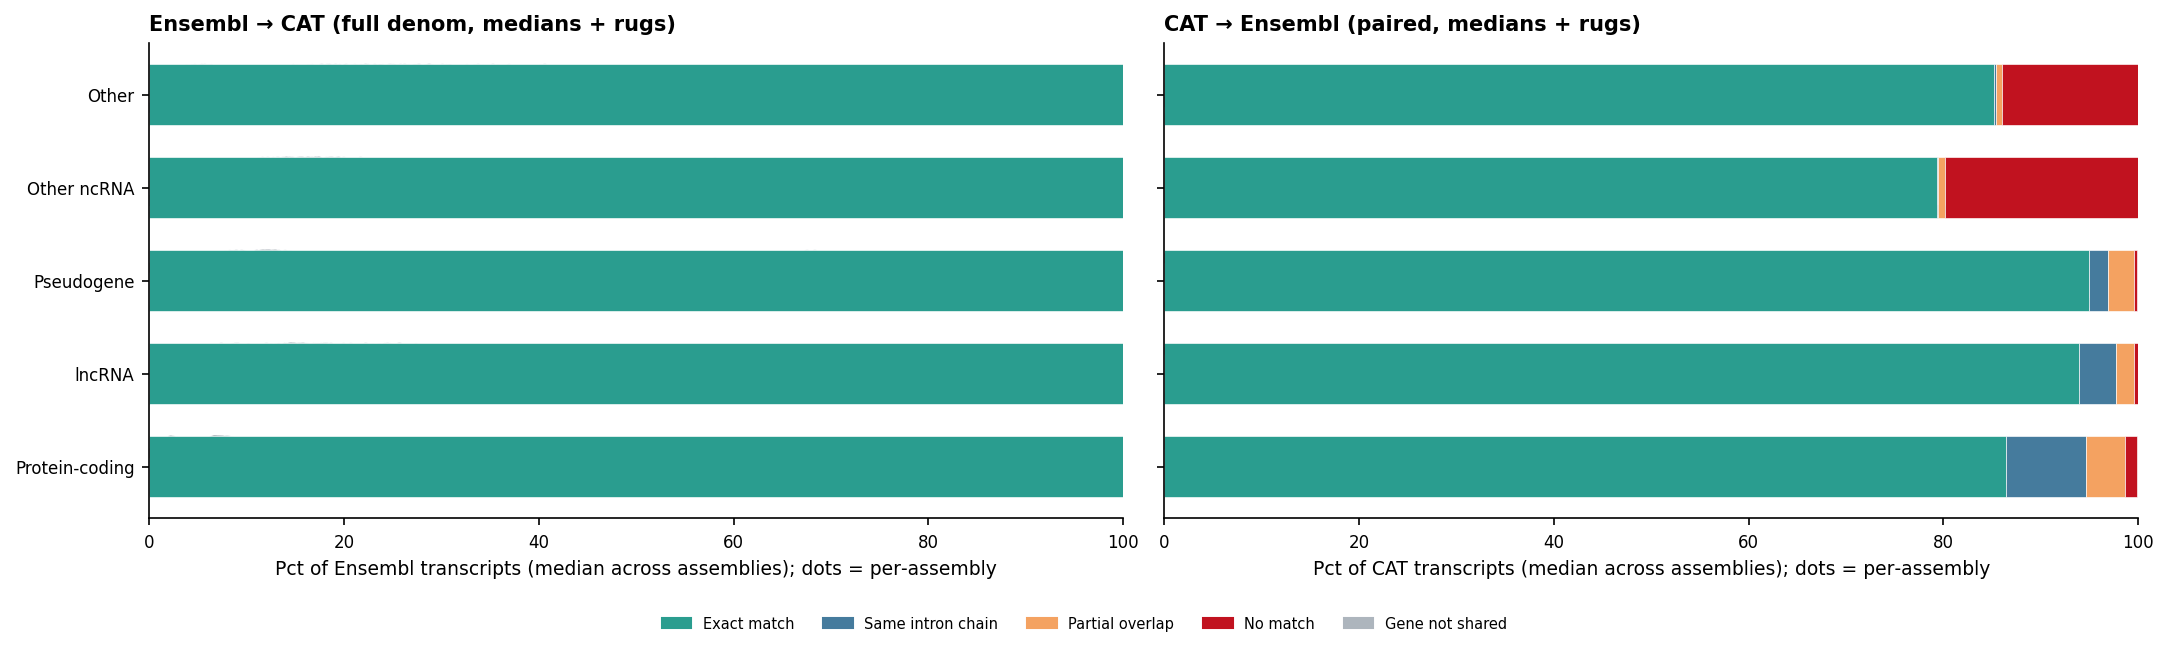

In [153]:

# Rug helpers for 5-group full-denom

def add_rung_dots_5group(ax, fd_df, biotype_order, group5_colors, y_positions,
                          group_order=None, y_offsets=None, alpha=0.18, size=6, seed=42):
    if fd_df is None or fd_df.empty:
        return
    rng = np.random.default_rng(seed)
    group_order = group_order or GROUP_5_ORDER
    y_offsets = y_offsets or {
        'Exact match':       -0.28,
        'Same intron chain': -0.14,
        'Partial overlap':    0.00,
        'No match':           0.14,
        'Gene not shared':    0.28,
    }
    df = fd_df.copy()
    df['group'] = df['classification'].map(FULL_DENOM_GROUP_MAP)
    asm = (df.groupby(['assembly_accession','biotype','group'])['pct']
             .sum().reset_index())
    for j, bio in enumerate(biotype_order):
        bio_df = asm[asm['biotype'] == bio]
        for g in group_order:
            vals = bio_df[bio_df['group'] == g]['pct'].to_numpy()
            if vals.size == 0:
                continue
            yj = y_positions[j] + y_offsets[g] + rng.uniform(-0.03, 0.03, size=vals.size)
            ax.scatter(vals, yj, s=size, alpha=alpha, color=group5_colors[g], edgecolors='none', zorder=1)

# Build tidy data for rugs (5-group)

def build_rug_dataset_5group(fd_df, biotype_order, group_order):
    if fd_df is None or fd_df.empty:
        return pd.DataFrame()
    df = fd_df.copy(); df['group'] = df['classification'].map(FULL_DENOM_GROUP_MAP)
    asm = (df.groupby(['assembly_accession','biotype','group'])['pct']
             .sum().reset_index().rename(columns={'pct':'value'}))
    asm['kind'] = 'assembly'
    med = (asm.groupby(['biotype','group'])['value']
             .median().reset_index())
    med['assembly_accession'] = ''
    med['kind'] = 'median'
    out = pd.concat([asm[['assembly_accession','biotype','group','value','kind']],
                     med[['assembly_accession','biotype','group','value','kind']]], ignore_index=True)
    out['biotype'] = pd.Categorical(out['biotype'], categories=biotype_order, ordered=True)
    out['group'] = pd.Categorical(out['group'], categories=group_order, ordered=True)
    return out.sort_values(['kind','biotype','group','assembly_accession'])

# Create figure
if not fd_data2.empty and not ic_data.empty:
    # Precompute medians if not available from prior cell
    # Left medians
    fd_tmp = fd_data2.copy(); fd_tmp['group'] = fd_tmp['classification'].map(FULL_DENOM_GROUP_MAP)
    fd_grouped = (fd_tmp.groupby(['assembly_accession','biotype','group'])['pct']
                        .sum().reset_index())
    fd_med5 = (fd_grouped.groupby(['biotype','group'])['pct']
                         .median().reset_index())
    fd_med5 = (fd_med5.pivot(index='biotype', columns='group', values='pct')
                      .reindex(index=BIOTYPE_ORDER, columns=GROUP_5_ORDER, fill_value=0))

    # Right medians
    dir_data = ic_data[ic_data['direction'] == 'CAT_to_Ensembl']
    stats = (dir_data.groupby(['biotype','classification'])['pct']
                      .agg(median_pct='median')
                      .reset_index())
    stats['group'] = stats['classification'].map(GROUP_4_MAP)
    stats4 = (stats.groupby(['biotype','group'])['median_pct'].sum().reset_index())
    med4_cat = (stats4.pivot(index='biotype', columns='group', values='median_pct')
                       .reindex(index=BIOTYPE_ORDER, columns=GROUP_4_ORDER, fill_value=0))

    # Export tidy rugs data
    left_rug = build_rug_dataset_5group(fd_data2, BIOTYPE_ORDER, GROUP_5_ORDER).assign(side='Ensembl_to_CAT_full_denom')
    right_rug = build_rug_dataset_4group(ic_data, 'CAT_to_Ensembl', BIOTYPE_ORDER, GROUP_4_MAP, GROUP_4_ORDER).assign(side='CAT_to_Ensembl_paired')
    rugs = pd.concat([left_rug, right_rug], ignore_index=True)
    save_data(rugs, 'panel_B_full_denom_vs_reverse_medians_rugs')

    fig, axes = plt.subplots(1, 2, figsize=(14.5, 4), sharey=True)

    # Left plot (5-group with rugs)
    ax = axes[0]
    y_pos = np.arange(len(BIOTYPE_ORDER))
    add_rung_dots_5group(ax, fd_data2, BIOTYPE_ORDER, GROUP_5_COLORS, y_pos, group_order=GROUP_5_ORDER)
    left = np.zeros(len(BIOTYPE_ORDER))
    for grp in GROUP_5_ORDER:
        v = fd_med5[grp].values
        ax.barh(y_pos, v, left=left, height=0.65,
                color=GROUP_5_COLORS[grp], edgecolor='white', linewidth=0.3, zorder=2)
        left += v
    ax.set_yticks(y_pos); ax.set_yticklabels([BIOTYPE_LABELS[b] for b in BIOTYPE_ORDER])
    ax.set_xlim(0,100); ax.invert_yaxis(); ax.set_title('Ensembl → CAT (full denom, medians + rugs)', fontsize=10, fontweight='bold', loc='left')
    ax.set_xlabel('Pct of Ensembl transcripts (median across assemblies); dots = per‑assembly')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

    # Right plot (4-group with rugs)
    ax = axes[1]
    add_rung_dots_4group(ax, ic_data, 'CAT_to_Ensembl', BIOTYPE_ORDER, GROUP_4_MAP, GROUP_4_COLORS, y_pos, group_order=GROUP_4_ORDER)
    left = np.zeros(len(BIOTYPE_ORDER))
    for grp in GROUP_4_ORDER:
        v = med4_cat[grp].values
        ax.barh(y_pos, v, left=left, height=0.65,
                color=GROUP_4_COLORS[grp], edgecolor='white', linewidth=0.3, zorder=2)
        left += v
    ax.set_yticks(y_pos); ax.set_yticklabels([BIOTYPE_LABELS[b] for b in BIOTYPE_ORDER])
    ax.set_xlim(0,100); ax.invert_yaxis(); ax.set_title('CAT → Ensembl (paired, medians + rugs)', fontsize=10, fontweight='bold', loc='left')
    ax.set_xlabel('Pct of CAT transcripts (median across assemblies); dots = per‑assembly')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

    # Combined legend
    from collections import OrderedDict
    used = OrderedDict()
    for g in GROUP_5_ORDER:
        used[g] = GROUP_5_COLORS[g]
    for g in GROUP_4_ORDER:
        used.setdefault(g, GROUP_4_COLORS[g])
    handles = [mpatches.Patch(color=c, label=g) for g, c in used.items()]
    fig.legend(handles=handles, loc='lower center', bbox_to_anchor=(0.5, -0.08), ncol=5, fontsize=7, frameon=False)

    plt.tight_layout(); save_panel(fig, 'panel_B_full_denom_vs_reverse_medians_rugs'); plt.show()
else:
    print('Skipping side-by-side rugs — need fd_data2 and ic_data.')


### Full‑denominator in both directions (medians)If full‑denominator data exist for both directions, this plots 5 groups for Ensembl→CAT and CAT→Ensembl side‑by‑side using median % across assemblies per biotype.

  Saved panel_B_full_denom_both_medians_data.tsv  (50 rows)
  Saved panel_B_full_denom_both_medians.{pdf,png}


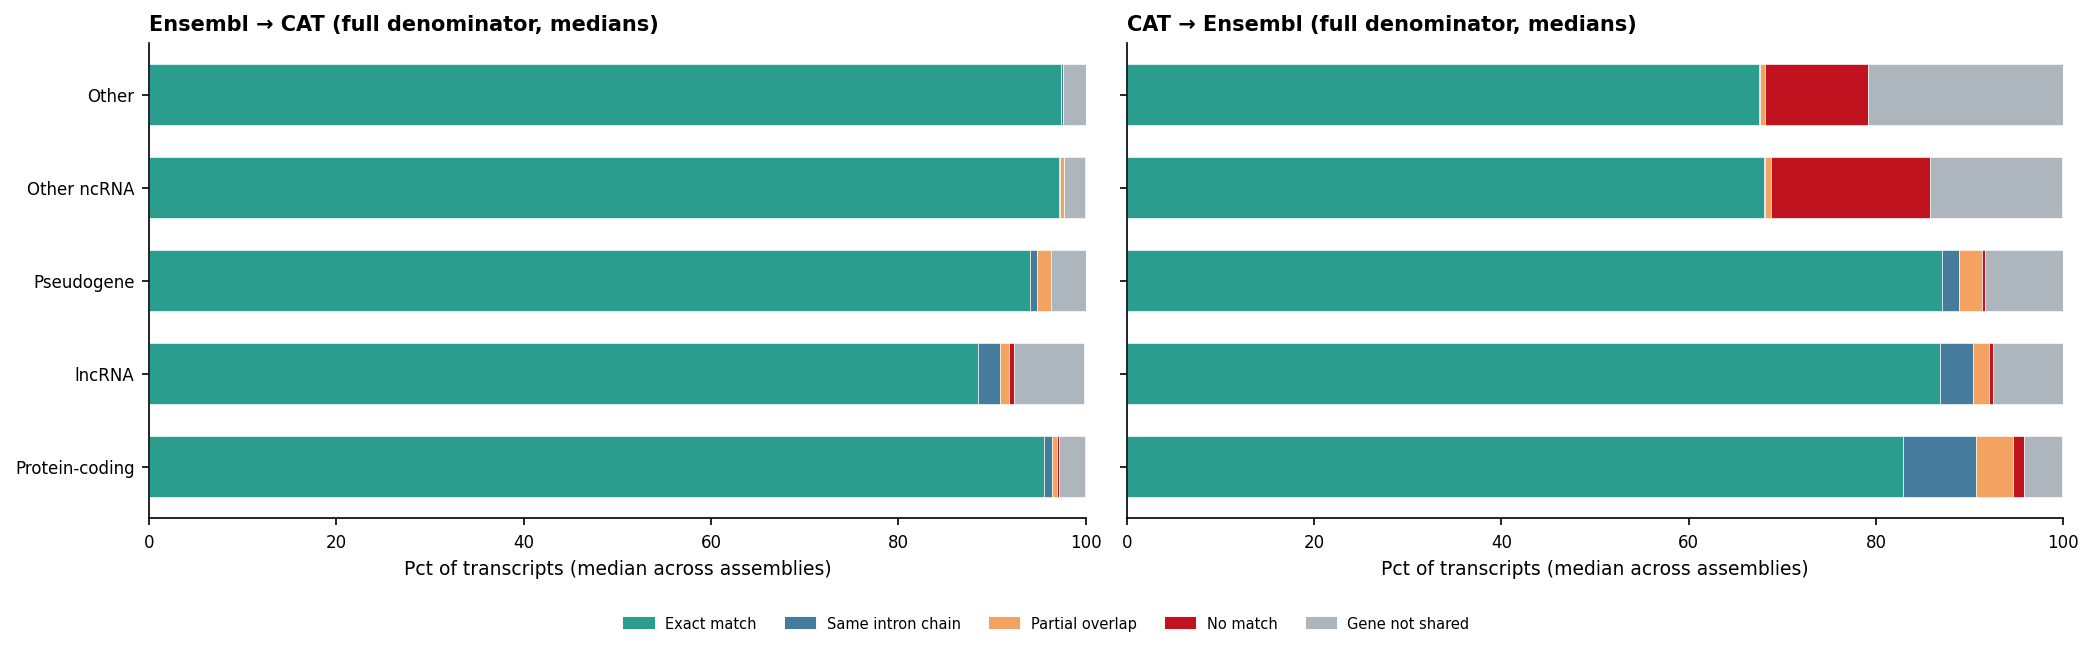

In [154]:

full_denom_file = INTRON_DIR / 'intron_chain_full_denom_per_assembly.tsv'
if 'fd_data2' not in globals():
    fd_data2 = pd.read_csv(full_denom_file, sep='	') if full_denom_file.exists() else pd.DataFrame()

if not fd_data2.empty and 'direction' in fd_data2.columns and set(fd_data2['direction'].unique()) >= {'Ensembl_to_CAT','CAT_to_Ensembl'}:
    fd_tmp = fd_data2.copy()
    fd_tmp['group'] = fd_tmp['classification'].map(FULL_DENOM_GROUP_MAP)
    grouped = (fd_tmp.groupby(['direction','assembly_accession','biotype','group'])['pct']
                      .sum().reset_index())
    med = (grouped.groupby(['direction','biotype','group'])['pct']
                  .median().reset_index())

    med_ens = (med[med['direction']=='Ensembl_to_CAT']
               .pivot(index='biotype', columns='group', values='pct')
               .reindex(index=BIOTYPE_ORDER, columns=GROUP_5_ORDER, fill_value=0))
    med_cat = (med[med['direction']=='CAT_to_Ensembl']
               .pivot(index='biotype', columns='group', values='pct')
               .reindex(index=BIOTYPE_ORDER, columns=GROUP_5_ORDER, fill_value=0))

    tidy = med.copy()
    save_data(tidy, 'panel_B_full_denom_both_medians')

    fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
    for ax, m, title in [
        (axes[0], med_ens, 'Ensembl → CAT (full denominator, medians)'),
        (axes[1], med_cat, 'CAT → Ensembl (full denominator, medians)')
    ]:
        y_pos = np.arange(len(BIOTYPE_ORDER))
        left = np.zeros(len(BIOTYPE_ORDER))
        for grp in GROUP_5_ORDER:
            v = m[grp].values
            ax.barh(y_pos, v, left=left, height=0.65,
                    color=GROUP_5_COLORS[grp], edgecolor='white', linewidth=0.3)
            left += v
        ax.set_yticks(y_pos); ax.set_yticklabels([BIOTYPE_LABELS[b] for b in BIOTYPE_ORDER])
        ax.set_xlim(0,100); ax.invert_yaxis(); ax.set_title(title, fontsize=10, fontweight='bold', loc='left')
        ax.set_xlabel('Pct of transcripts (median across assemblies)')
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    handles = [mpatches.Patch(color=GROUP_5_COLORS[g], label=g) for g in GROUP_5_ORDER]
    fig.legend(handles=handles, loc='lower center', bbox_to_anchor=(0.5, -0.08), ncol=5, fontsize=7, frameon=False)
    plt.tight_layout(); save_panel(fig, 'panel_B_full_denom_both_medians'); plt.show()
else:
    print('Skipping full-denominator both-directions medians — need both directions present in full-denominator file.')


### Full‑denominator in both directions (rugs)Semi‑transparent per‑assembly dots behind 5‑group median stacks for both directions.

  Saved panel_B_full_denom_both_medians_rugs_data.tsv  (23150 rows)
  Saved panel_B_full_denom_both_medians_rugs.{pdf,png}


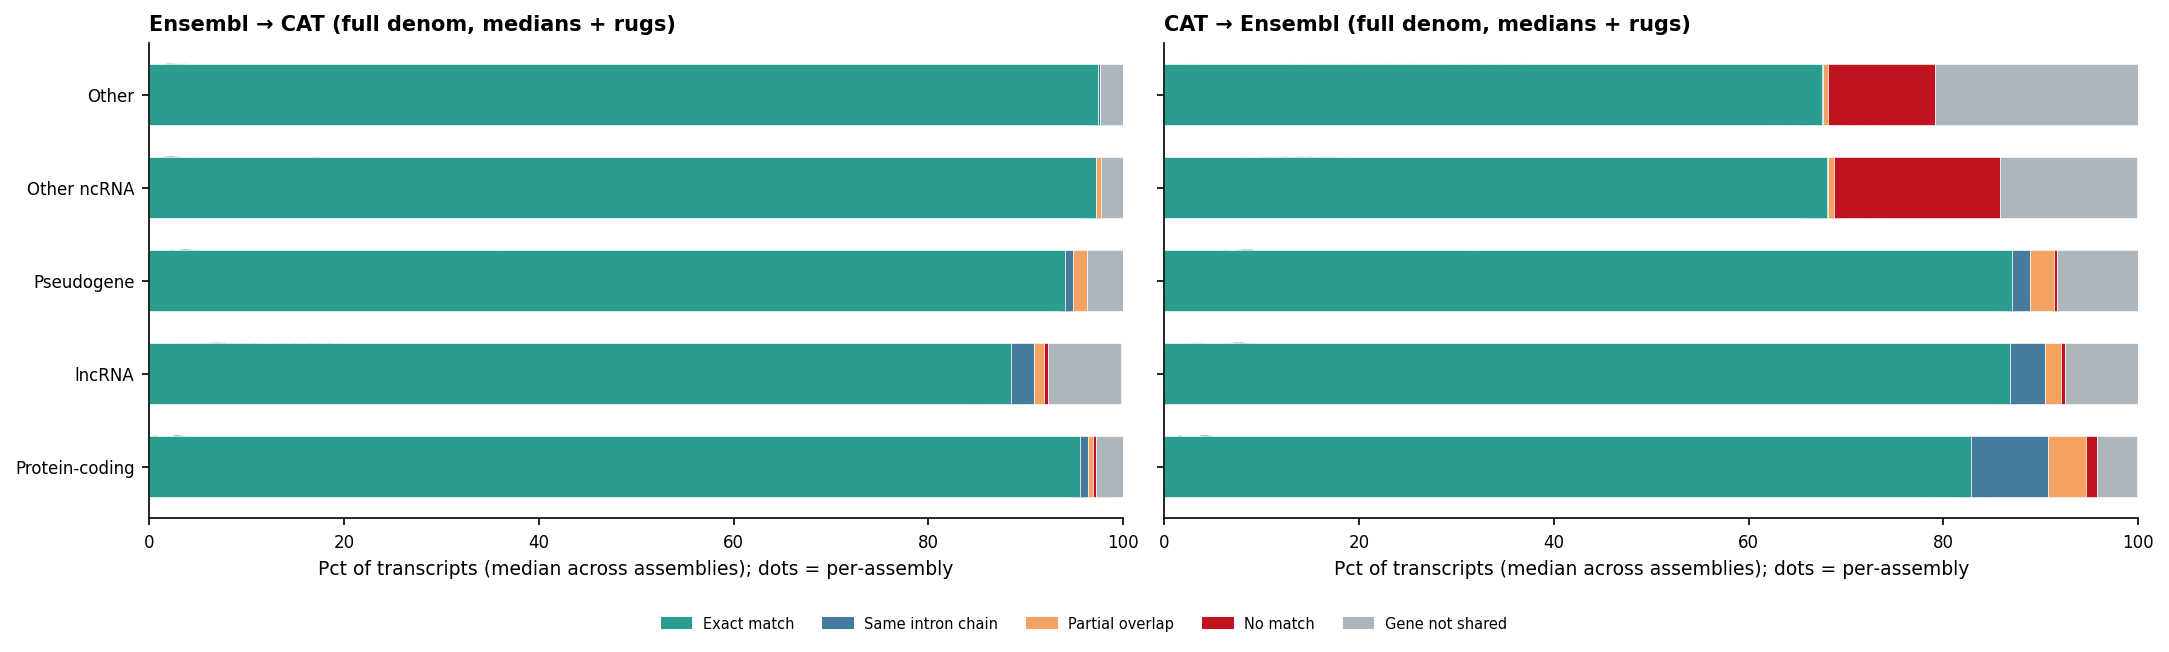

In [155]:

# Build rugs for a given direction from full-denominator df

def build_fd_rugs(fd_df, direction):
    if fd_df is None or fd_df.empty:
        return pd.DataFrame()
    df = fd_df[fd_df['direction']==direction].copy()
    if df.empty:
        return pd.DataFrame()
    df['group'] = df['classification'].map(FULL_DENOM_GROUP_MAP)
    asm = (df.groupby(['assembly_accession','biotype','group'])['pct']
             .sum().reset_index().rename(columns={'pct':'value'}))
    asm['kind'] = 'assembly'
    med = (asm.groupby(['biotype','group'])['value']
             .median().reset_index())
    med['assembly_accession'] = ''
    med['kind'] = 'median'
    out = pd.concat([asm[['assembly_accession','biotype','group','value','kind']],
                     med[['assembly_accession','biotype','group','value','kind']]], ignore_index=True)
    out['biotype'] = pd.Categorical(out['biotype'], categories=BIOTYPE_ORDER, ordered=True)
    out['group'] = pd.Categorical(out['group'], categories=GROUP_5_ORDER, ordered=True)
    out['direction'] = direction
    return out.sort_values(['kind','biotype','group','assembly_accession'])

if not fd_data2.empty and set(fd_data2.get('direction', pd.Series([])).unique()) >= {'Ensembl_to_CAT','CAT_to_Ensembl'}:
    ens_rugs = build_fd_rugs(fd_data2, 'Ensembl_to_CAT')
    cat_rugs = build_fd_rugs(fd_data2, 'CAT_to_Ensembl')
    rugs = pd.concat([ens_rugs, cat_rugs], ignore_index=True)
    save_data(rugs, 'panel_B_full_denom_both_medians_rugs')

    # Prepare medians for plotting
    def med5(df, direction):
        tmp = df[df['direction']==direction].copy()
        tmp['group'] = tmp['classification'].map(FULL_DENOM_GROUP_MAP)
        grouped = (tmp.groupby(['assembly_accession','biotype','group'])['pct']
                      .sum().reset_index())
        med = (grouped.groupby(['biotype','group'])['pct']
                      .median().reset_index())
        return (med.pivot(index='biotype', columns='group', values='pct')
                    .reindex(index=BIOTYPE_ORDER, columns=GROUP_5_ORDER, fill_value=0))

    med_ens = med5(fd_data2, 'Ensembl_to_CAT')
    med_cat = med5(fd_data2, 'CAT_to_Ensembl')

    fig, axes = plt.subplots(1, 2, figsize=(14.5, 4), sharey=True)
    for ax, direction, title, medw in [
        (axes[0], 'Ensembl_to_CAT', 'Ensembl → CAT (full denom, medians + rugs)', med_ens),
        (axes[1], 'CAT_to_Ensembl', 'CAT → Ensembl (full denom, medians + rugs)', med_cat),
    ]:
        y_pos = np.arange(len(BIOTYPE_ORDER))
        # rugs
        add_rung_dots_5group(ax, fd_data2[fd_data2['direction']==direction], BIOTYPE_ORDER, GROUP_5_COLORS, y_pos, group_order=GROUP_5_ORDER)
        # bars
        left = np.zeros(len(BIOTYPE_ORDER))
        for grp in GROUP_5_ORDER:
            v = medw[grp].values
            ax.barh(y_pos, v, left=left, height=0.65,
                    color=GROUP_5_COLORS[grp], edgecolor='white', linewidth=0.3, zorder=2)
            left += v
        ax.set_yticks(y_pos); ax.set_yticklabels([BIOTYPE_LABELS[b] for b in BIOTYPE_ORDER])
        ax.set_xlim(0,100); ax.invert_yaxis(); ax.set_title(title, fontsize=10, fontweight='bold', loc='left')
        ax.set_xlabel('Pct of transcripts (median across assemblies); dots = per‑assembly')
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

    handles = [mpatches.Patch(color=GROUP_5_COLORS[g], label=g) for g in GROUP_5_ORDER]
    fig.legend(handles=handles, loc='lower center', bbox_to_anchor=(0.5, -0.08), ncol=5, fontsize=7, frameon=False)
    plt.tight_layout(); save_panel(fig, 'panel_B_full_denom_both_medians_rugs'); plt.show()
else:
    print('Skipping full-denominator rugs — need both directions present in full-denominator file.')


---## Feature Breakdown — Distributions for Ensembl vs CATGoal: give a simple global sense of each annotation set, independent of pairing, using the per‑assembly gene transcript count tables.Data: `qc_metrics/<accession>/*_gene_transcript_counts.tsv` (Ensembl) and `qc_metrics/<accession>/*_cat_gene_transcript_counts.tsv` (CAT), produced by count_gff_transcripts.py.

In [160]:

# Load per-gene transcript counts for Ensembl and CAT
from pathlib import Path

def group_biotype_simple(b: str) -> str:
    b = str(b or '').lower()
    if 'protein_coding' in b:
        return 'protein_coding'
    if 'lncrna' in b or 'lnc_rna' in b:
        return 'lncRNA'
    if 'pseudogene' in b or 'pseudogenic' in b:
        return 'pseudogene'
    if any(x in b for x in ['snrna','snorna','mirna','trna','rrna','ncrna','antisense','tec','guide_rna','scrna','vault_rna','y_rna']):
        return 'other_ncRNA'
    return 'other'

ensembl_files = sorted(QC_DIR.rglob('*_gene_transcript_counts.tsv'))
ensembl_files = [p for p in ensembl_files if '_cat_' not in p.name]

cat_files = sorted(QC_DIR.rglob('*_cat_gene_transcript_counts.tsv'))

print(f"Found {len(ensembl_files)} Ensembl count tables, {len(cat_files)} CAT count tables")

# Read with minimal columns to limit memory
usecols = ['assembly_accession','gene_id','biotype','n_transcripts']

ens_list, cat_list = [], []
for p in ensembl_files:
    try:
        df = pd.read_csv(p, sep='	', usecols=usecols, dtype={'gene_id':str,'biotype':str})
        df['source'] = 'Ensembl'
        ens_list.append(df)
    except Exception as e:
        print('WARN (Ensembl counts):', p, e)
for p in cat_files:
    try:
        df = pd.read_csv(p, sep='	', usecols=usecols, dtype={'gene_id':str,'biotype':str})
        df['source'] = 'CAT'
        cat_list.append(df)
    except Exception as e:
        print('WARN (CAT counts):', p, e)

counts_df = pd.concat(ens_list + cat_list, ignore_index=True) if (ens_list or cat_list) else pd.DataFrame()
if counts_df.empty:
    print('No gene transcript count tables found — skipping feature breakdown panels.')
else:
    counts_df['biotype_group'] = counts_df['biotype'].map(group_biotype_simple)
    counts_df['biotype_group'] = pd.Categorical(counts_df['biotype_group'], categories=BIOTYPE_ORDER, ordered=True)
    print('Counts loaded:', len(counts_df), 'rows', '| assemblies =', counts_df['assembly_accession'].nunique())


Found 462 Ensembl count tables, 462 CAT count tables
Counts loaded: 74515552 rows | assemblies = 462


### F1 — Biotype composition of genes (median % across assemblies)Each bar is 100% of genes for that source; segments are median % by grouped biotype across assemblies.

  Saved panel_F1_biotype_composition_data.tsv  (10 rows)
  Saved panel_F1_biotype_composition.{pdf,png}


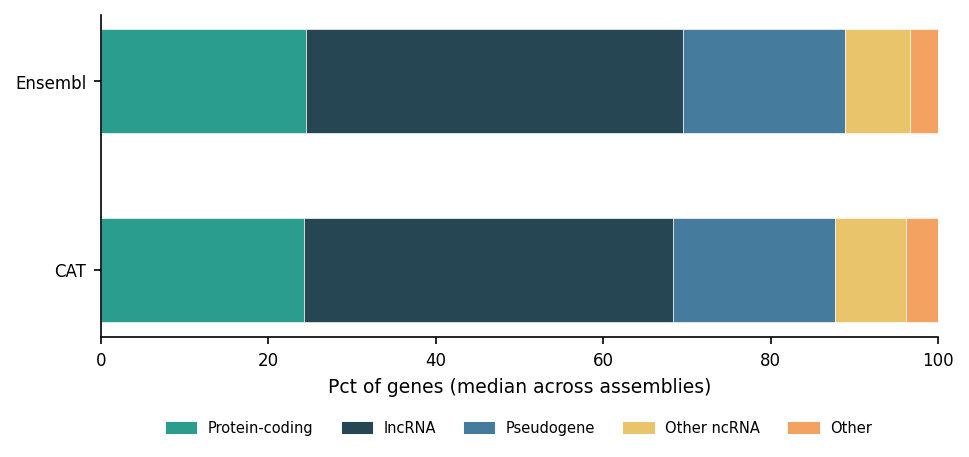

In [161]:

if counts_df.empty:
    print('Skipping F1 — no counts')
else:
    # Per assembly: % of genes by biotype
    per_asm = (counts_df.groupby(['source','assembly_accession','biotype_group'])['gene_id']
                        .nunique().reset_index(name='n_genes'))
    totals = per_asm.groupby(['source','assembly_accession'])['n_genes'].transform('sum')
    per_asm['pct'] = 100 * per_asm['n_genes'] / totals
    # Median across assemblies per source×biotype
    med = (per_asm.groupby(['source','biotype_group'])['pct']
                  .median().reset_index())
    wide = (med.pivot(index='source', columns='biotype_group', values='pct')
               .reindex(index=['Ensembl','CAT'], fill_value=0)
               .reindex(columns=BIOTYPE_ORDER, fill_value=0))

    save_data(med.rename(columns={'biotype_group':'biotype'}), 'panel_F1_biotype_composition')

    fig, ax = plt.subplots(figsize=(6.5, 3.2))
    y_pos = np.arange(len(wide.index))
    left = np.zeros(len(wide.index))
    palette = {
        'protein_coding': '#2a9d8f',
        'lncRNA': '#264653',
        'pseudogene': '#457b9d',
        'other_ncRNA': '#e9c46a',
        'other': '#f4a261',
    }
    for b in BIOTYPE_ORDER:
        v = wide[b].values
        ax.barh(y_pos, v, left=left, height=0.55,
                color=palette.get(b, '#999999'), edgecolor='white', linewidth=0.3, label=BIOTYPE_LABELS[b])
        left += v
    ax.set_yticks(y_pos); ax.set_yticklabels(wide.index)
    ax.set_xlim(0,100); ax.invert_yaxis()
    ax.set_xlabel('Pct of genes (median across assemblies)')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    handles = [mpatches.Patch(color=palette[b], label=BIOTYPE_LABELS[b]) for b in BIOTYPE_ORDER]
    ax.legend(handles=handles, loc='lower center', bbox_to_anchor=(0.5, -0.35), ncol=5, fontsize=7, frameon=False)
    plt.tight_layout(); save_panel(fig, 'panel_F1_biotype_composition'); plt.show()


### F2 — Transcripts per gene (distribution)For each source and biotype, we summarize per‑assembly distributions of `n_transcripts` per gene into box stats and plot median‑of‑medians across assemblies.

  Saved panel_F2_tx_per_gene_per_assembly_data.tsv  (4620 rows)
  Saved panel_F2_tx_per_gene_distribution.{pdf,png}


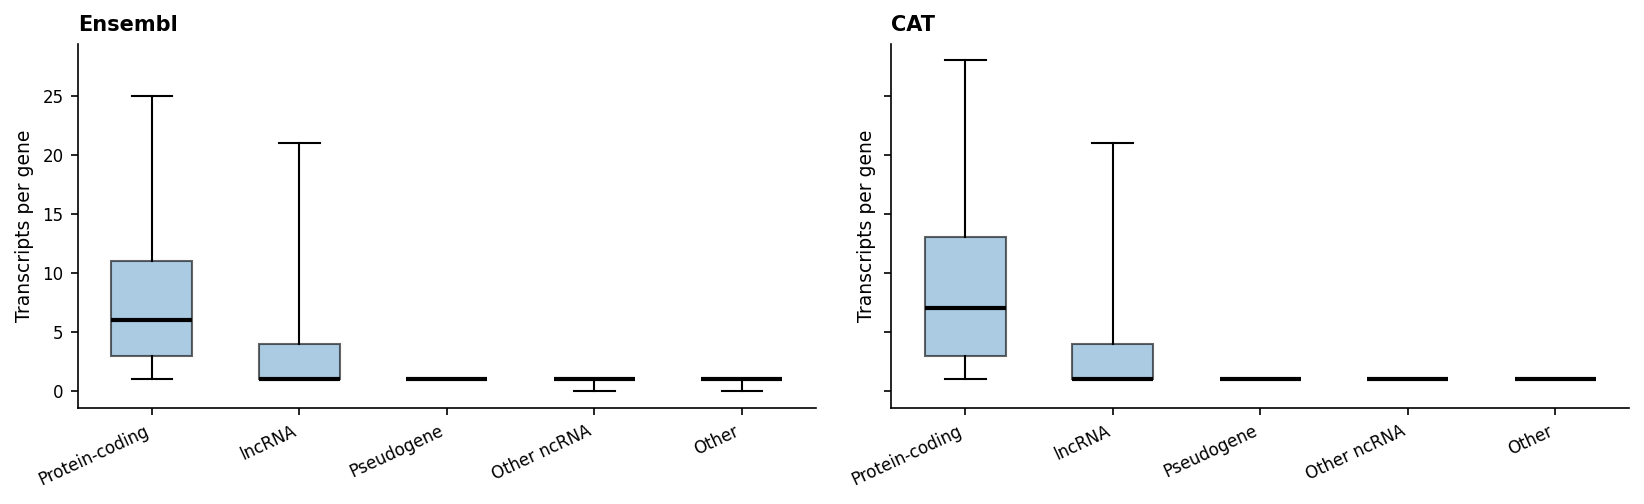

In [162]:

if counts_df.empty:
    print('Skipping F2 — no counts')
else:
    # Compute per-assembly quantiles, then median-of-quantiles across assemblies
    qstats = []
    for (src, bio, asm), grp in counts_df.groupby(['source','biotype_group','assembly_accession']):
        vals = pd.to_numeric(grp['n_transcripts'], errors='coerce').dropna()
        if len(vals) == 0:
            continue
        qstats.append({
            'source': src, 'biotype': bio, 'assembly_accession': asm,
            'med': float(vals.median()), 'q1': float(vals.quantile(0.25)), 'q3': float(vals.quantile(0.75)),
            'p5': float(vals.quantile(0.05)), 'p95': float(vals.quantile(0.95)), 'n_genes': int(len(vals))
        })
    qdf = pd.DataFrame(qstats)
    save_data(qdf, 'panel_F2_tx_per_gene_per_assembly')

    fig, axes = plt.subplots(1, 2, figsize=(11, 3.4), sharey=True)
    for ax, src in zip(axes, ['Ensembl','CAT']):
        sub = qdf[qdf['source']==src]
        stats, labels = [], []
        for b in BIOTYPE_ORDER:
            bsub = sub[sub['biotype']==b]
            if bsub.empty:
                continue
            stats.append({
                'med': bsub['med'].median(),
                'q1': bsub['q1'].median(), 'q3': bsub['q3'].median(),
                'whislo': bsub['p5'].median(), 'whishi': bsub['p95'].median(), 'fliers': []
            })
            labels.append(BIOTYPE_LABELS[b])
        pos = np.arange(1, len(stats)+1)
        bp = ax.bxp(stats, positions=pos, widths=0.55, patch_artist=True, showfliers=False, medianprops=dict(color='black', linewidth=2))
        for patch in bp['boxes']:
            patch.set_facecolor('#74a9cf'); patch.set_alpha(0.6)
        ax.set_xticks(pos); ax.set_xticklabels(labels, rotation=25, ha='right')
        ax.set_title(src, fontsize=10, fontweight='bold', loc='left')
        ax.set_ylabel('Transcripts per gene'); ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    plt.tight_layout(); save_panel(fig, 'panel_F2_tx_per_gene_distribution'); plt.show()


### F3 — Total counts per assembly (genes and transcripts)Side‑by‑side violins show per‑assembly totals for Ensembl vs CAT.

  Saved panel_F3_total_counts_per_assembly_data.tsv  (924 rows)
  Saved panel_F3_total_counts.{pdf,png}


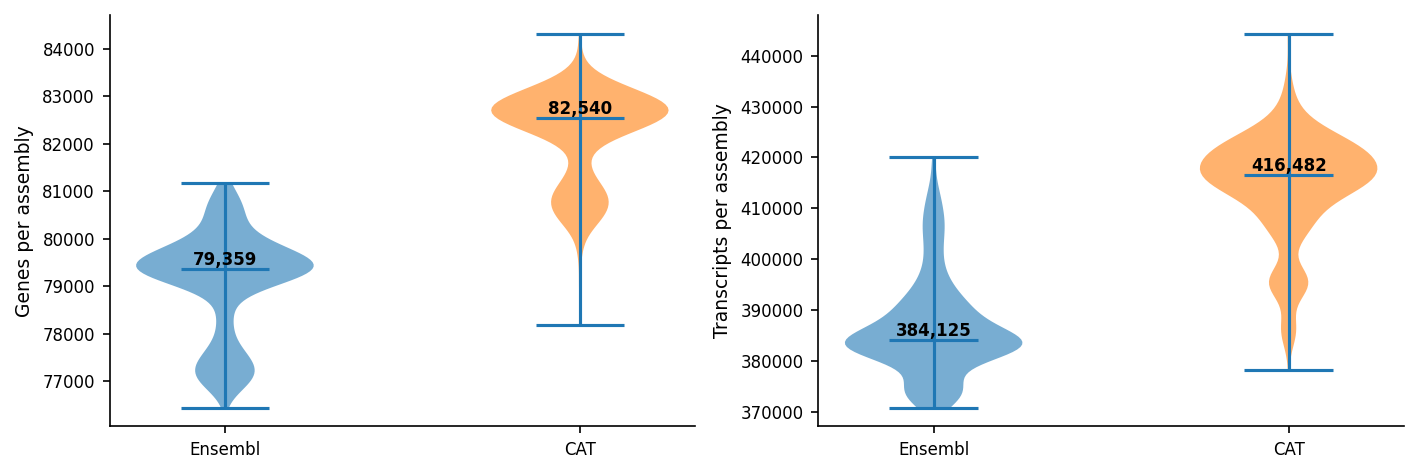

In [163]:

if counts_df.empty:
    print('Skipping F3 — no counts')
else:
    totals = (counts_df.groupby(['source','assembly_accession'])
                        .agg(n_genes=('gene_id','nunique'), n_transcripts=('n_transcripts','sum'))
                        .reset_index())
    save_data(totals, 'panel_F3_total_counts_per_assembly')

    fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.2), sharey=False)
    for ax, metric, label in [
        (axes[0], 'n_genes', 'Genes per assembly'),
        (axes[1], 'n_transcripts', 'Transcripts per assembly'),
    ]:
        data = [totals[totals['source']==src][metric].values for src in ['Ensembl','CAT']]
        parts = ax.violinplot(data, positions=[1,2], showmedians=True)
        colors = ['#1f77b4','#ff7f0e']
        for pc, col in zip(parts['bodies'], colors):
            pc.set_facecolor(col); pc.set_alpha(0.6)
        ax.set_xticks([1,2]); ax.set_xticklabels(['Ensembl','CAT'])
        ax.set_ylabel(label); ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
        for i, d in enumerate(data):
            if len(d):
                m = float(pd.Series(d).median())
                ax.text(i+1, m, f'{int(m):,}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    plt.tight_layout(); save_panel(fig, 'panel_F3_total_counts'); plt.show()
